In [43]:
# ============================================================
# Cell 1: Import Required Libraries and Define STK CSV Files
# This cell imports the required Python libraries and defines
# the five STK J2000 Position Velocity CSV files.
# ============================================================

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path
from itertools import combinations

MU = 398600.4418  # Earth gravitational parameter in km^3/s^2

files = {
    "Orbit 1": "Satellite1 J2000 Position Velocity.csv",
    "Orbit 2": "Satellite2 J2000 Position Velocity orbit 2.csv",
    "Orbit 3": "Satellite3 J2000 Position Velocity orbit 3.csv",
    "Orbit 4": "Satellite4 J2000 Position Velocity orbit 4.csv",
    "Orbit 5": "Satellite5 J2000 Position Velocity orbit 5.csv",
}

In [44]:
# ============================================================
# Cell 2: Read and Clean STK J2000 Position Velocity Data
# This cell reads the STK CSV files, standardizes column names,
# keeps the first 15 points, and converts time to seconds.
# ============================================================

def read_stk_csv(file_path, n_points=15):
    df = pd.read_csv(file_path)
    df.columns = [c.strip().lower() for c in df.columns]

    rename = {
        "time (utcg)": "time",
        "x (km)": "x",
        "y (km)": "y",
        "z (km)": "z",
        "vx (km/sec)": "vx",
        "vy (km/sec)": "vy",
        "vz (km/sec)": "vz",
    }

    df = df.rename(columns=rename)

    needed = ["time", "x", "y", "z", "vx", "vy", "vz"]
    df = df[needed].head(n_points).copy()

    df["time"] = pd.to_datetime(df["time"])
    df["t_sec"] = (df["time"] - df["time"].iloc[0]).dt.total_seconds()

    return df


orbit_data = {}

for name, file in files.items():
    df = read_stk_csv(file, n_points=15)
    orbit_data[name] = df
    print(f"{name}: {df.shape[0]} points loaded")
    display(df.head())

Orbit 1: 15 points loaded


,time,x,y,z,vx,vy,vz,t_sec
0,2026-04-25 09:00:00,6877.994131,-40.660031,-17.666028,0.045648,5.383016,5.382644,0.0
1,2026-04-25 09:01:00,6865.550924,282.173278,305.544335,-0.459954,5.374139,5.372046,60.0
2,2026-04-25 09:02:00,6822.800249,603.762946,627.403904,-0.963525,5.341572,5.337699,120.0
3,2026-04-25 09:03:00,6749.930832,922.691321,946.489872,-1.462842,5.285458,5.279757,180.0
4,2026-04-25 09:04:00,6647.264358,1237.552482,1261.391693,-1.955702,5.206044,5.198475,240.0


Orbit 2: 15 points loaded


,time,x,y,z,vx,vy,vz,t_sec
0,2026-04-25 09:00:00,26377.589087,-155.934068,-67.750455,0.023309,2.748774,2.748584,0.0
1,2026-04-25 09:05:00,26358.803350,668.581857,756.700624,-0.148520,2.747104,2.746339,300.0
2,2026-04-25 09:10:00,26288.501381,1491.791243,1579.672638,-0.320060,2.740065,2.738726,600.0
3,2026-04-25 09:15:00,26166.820578,2312.085345,2399.556999,-0.490974,2.727671,2.725760,900.0
4,2026-04-25 09:20:00,25993.998759,3127.861114,3214.751154,-0.660928,2.709947,2.707466,1200.0


Orbit 3: 15 points loaded


,time,x,y,z,vx,vy,vz,t_sec
0,2026-04-25 09:00:00,42163.261188,-249.252834,-108.295725,0.018175,3.074608,-0.000151,0.0
1,2026-04-25 09:10:00,42133.807633,1595.298753,-108.282780,-0.116331,3.072460,0.000194,600.0
2,2026-04-25 09:20:00,42023.698092,3436.796488,-108.062551,-0.250615,3.064430,0.000540,1200.0
3,2026-04-25 09:30:00,41833.143345,5271.715225,-107.635460,-0.384419,3.050535,0.000884,1800.0
4,2026-04-25 09:40:00,41562.508168,7096.542413,-107.002325,-0.517487,3.030800,0.001226,2400.0


Orbit 4: 15 points loaded


,time,x,y,z,vx,vy,vz,t_sec
0,2026-04-25 09:00:00,6877.994131,-40.660031,-17.666028,0.019554,0.000259,7.612583,0.0
1,2026-04-25 09:01:00,6864.047116,-40.555165,438.156428,-0.484934,0.003240,7.597146,60.0
2,2026-04-25 09:02:00,6819.925853,-40.272019,892.052756,-0.987290,0.006208,7.548313,120.0
3,2026-04-25 09:03:00,6745.824297,-39.811837,1342.027632,-1.485306,0.009148,7.466297,180.0
4,2026-04-25 09:04:00,6642.068198,-39.176643,1786.102976,-1.976793,0.012047,7.351459,240.0


Orbit 5: 15 points loaded


,time,x,y,z,vx,vy,vz,t_sec
0,2026-04-25 09:00:00,-2872.429922,1150.637887,-6142.796381,-3.753443,-9.316860,0.009958,0.0
1,2026-04-25 09:01:00,-3091.131089,589.542590,-6128.672513,-3.534602,-9.380735,0.460327,60.0
2,2026-04-25 09:02:00,-3296.288192,25.860248,-6087.688106,-3.302488,-9.403146,0.904331,120.0
3,2026-04-25 09:03:00,-3487.211295,-537.940900,-6020.406314,-3.060688,-9.384963,1.336016,180.0
4,2026-04-25 09:04:00,-3663.430767,-1099.483516,-5927.728400,-2.812922,-9.328317,1.750113,240.0


In [45]:
# ============================================================
# Cell 3: Calculate Orbital Elements from Position and Velocity
# This function calculates the classical orbital elements from
# position vector r and velocity vector v.
# ============================================================

def orbital_elements_from_rv(r, v, mu=MU):
    r = np.array(r, dtype=float)
    v = np.array(v, dtype=float)

    r_norm = np.linalg.norm(r)
    v_norm = np.linalg.norm(v)

    h = np.cross(r, v)
    h_norm = np.linalg.norm(h)

    i = np.degrees(np.arccos(h[2] / h_norm))

    K = np.array([0, 0, 1])
    n = np.cross(K, h)
    n_norm = np.linalg.norm(n)

    e_vec = (np.cross(v, h) / mu) - (r / r_norm)
    e = np.linalg.norm(e_vec)

    energy = (v_norm**2 / 2) - (mu / r_norm)
    a = -mu / (2 * energy)

    if n_norm != 0:
        RAAN = np.degrees(np.arccos(n[0] / n_norm))
        if n[1] < 0:
            RAAN = 360 - RAAN
    else:
        RAAN = 0

    if n_norm != 0 and e > 1e-8:
        arg_perigee = np.degrees(np.arccos(np.dot(n, e_vec) / (n_norm * e)))
        if e_vec[2] < 0:
            arg_perigee = 360 - arg_perigee
    else:
        arg_perigee = 0

    if e > 1e-8:
        true_anomaly = np.degrees(np.arccos(np.dot(e_vec, r) / (e * r_norm)))
        if np.dot(r, v) < 0:
            true_anomaly = 360 - true_anomaly
    else:
        true_anomaly = 0

    rp = a * (1 - e)
    ra = a * (1 + e)

    if i < 10:
        direction = "Prograde / Near-equatorial"
    elif i > 90:
        direction = "Retrograde"
    elif abs(i - 90) < 10:
        direction = "Polar"
    else:
        direction = "Prograde Inclined"

    return {
        "a_km": a,
        "e": e,
        "i_deg": i,
        "RAAN_deg": RAAN,
        "arg_perigee_deg": arg_perigee,
        "true_anomaly_deg": true_anomaly,
        "rp_km": rp,
        "ra_km": ra,
        "direction": direction
    }

In [46]:
# ============================================================
# Cell 4: Calculate Orbital Elements Using Random STK Points
# This cell randomly selects two points from each orbit.
# The first point position and velocity are used to calculate
# orbital elements, while the second point is kept for validation.
# ============================================================

np.random.seed(42)

summary = []

for name, df in orbit_data.items():
    idx = np.random.choice(df.index, size=2, replace=False)
    idx = sorted(idx)

    p1 = df.loc[idx[0]]
    p2 = df.loc[idx[1]]

    r1 = p1[["x", "y", "z"]].values
    v1 = p1[["vx", "vy", "vz"]].values

    elements = orbital_elements_from_rv(r1, v1)

    summary.append({
        "Orbit": name,
        "Point 1 index": idx[0],
        "Point 2 index": idx[1],
        **elements
    })

summary_df = pd.DataFrame(summary)
summary_df

,Orbit,Point 1 index,Point 2 index,a_km,e,i_deg,RAAN_deg,arg_perigee_deg,true_anomaly_deg,rp_km,ra_km,direction
0,Orbit 1,9,11,6878.136577,6.310420e-08,44.997285,359.774649,200.937628,193.145638,6878.136143,6878.137011,Prograde Inclined
1,Orbit 2,10,12,26378.127533,3.589219e-07,44.997367,359.806768,204.555401,180.569543,26378.118065,26378.137001,Prograde Inclined
2,Orbit 3,1,12,42164.143015,1.440825e-07,0.147187,90.760911,263.331754,8.075666,42164.136939,42164.149090,Prograde / Near-equatorial
3,Orbit 4,2,7,6878.137716,1.065553e-07,89.997179,359.661300,19.759711,347.692196,6878.136983,6878.138449,Polar
4,Orbit 5,8,10,26553.385422,7.409695e-01,63.264230,248.027743,270.063611,37.695703,6878.137083,46228.633762,Prograde Inclined


In [47]:
# ============================================================
# Cell 5: Simple Euler-Cromer Orbit Propagator
# This cell defines a simple two-body propagation model to
# predict satellite position over time.
# ============================================================

def acceleration(r, mu=MU):
    r_norm = np.linalg.norm(r)
    return -mu * r / r_norm**3


def propagate_orbit(r0, v0, times):
    r = np.array(r0, dtype=float)
    v = np.array(v0, dtype=float)

    predicted = []
    last_t = times[0]

    for t in times:
        dt = t - last_t

        a = acceleration(r)
        v = v + a * dt
        r = r + v * dt

        predicted.append(r.copy())
        last_t = t

    return np.array(predicted)

In [48]:
# ============================================================
# Cell 6: Predict Orbits and Compare with STK Reference Data
# This cell propagates each orbit and calculates the position
# error and RMSE compared with STK data.
# ============================================================

results = {}

for name, df in orbit_data.items():
    r0 = df.loc[0, ["x", "y", "z"]].values
    v0 = df.loc[0, ["vx", "vy", "vz"]].values
    times = df["t_sec"].values

    pred = propagate_orbit(r0, v0, times)
    actual = df[["x", "y", "z"]].values

    errors = np.linalg.norm(pred - actual, axis=1)
    rmse = np.sqrt(np.mean(errors**2))

    results[name] = {
        "pred": pred,
        "actual": actual,
        "errors": errors,
        "rmse": rmse
    }

    print(f"{name} RMSE = {rmse:.3f} km")

Orbit 1 RMSE = 142.326 km
Orbit 2 RMSE = 227.940 km
Orbit 3 RMSE = 356.194 km
Orbit 4 RMSE = 147.131 km
Orbit 5 RMSE = 139.399 km


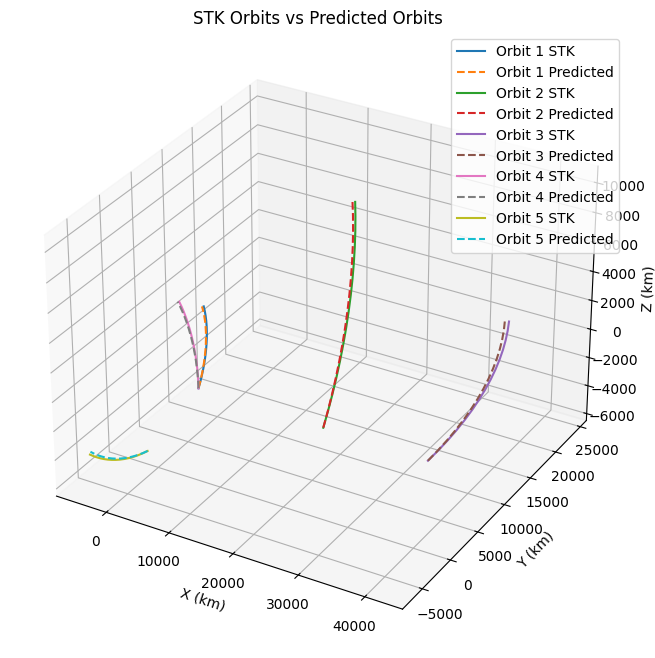

In [49]:
# ============================================================
# Cell 7: Plot STK Orbits vs Predicted Orbits in 3D
# This cell visualizes the original STK orbit and the predicted
# orbit for the five satellites.
# ============================================================

fig = plt.figure(figsize=(10, 8))
ax = fig.add_subplot(111, projection="3d")

for name, res in results.items():
    actual = res["actual"]
    pred = res["pred"]

    ax.plot(actual[:, 0], actual[:, 1], actual[:, 2], label=f"{name} STK")
    ax.plot(pred[:, 0], pred[:, 1], pred[:, 2], linestyle="--", label=f"{name} Predicted")

ax.set_title("STK Orbits vs Predicted Orbits")
ax.set_xlabel("X (km)")
ax.set_ylabel("Y (km)")
ax.set_zlabel("Z (km)")
ax.legend()
plt.show()

In [50]:
# ============================================================
# Cell 8: Create Final Orbital Elements Report
# This cell combines the calculated orbital elements with the
# prediction RMSE into one final report table.
# ============================================================

report = summary_df.copy()
report["RMSE_km"] = [results[name]["rmse"] for name in report["Orbit"]]

report = report[
    [
        "Orbit",
        "Point 1 index",
        "Point 2 index",
        "a_km",
        "e",
        "i_deg",
        "RAAN_deg",
        "arg_perigee_deg",
        "true_anomaly_deg",
        "rp_km",
        "ra_km",
        "direction",
        "RMSE_km"
    ]
]

report

,Orbit,Point 1 index,Point 2 index,a_km,e,i_deg,RAAN_deg,arg_perigee_deg,true_anomaly_deg,rp_km,ra_km,direction,RMSE_km
0,Orbit 1,9,11,6878.136577,6.310420e-08,44.997285,359.774649,200.937628,193.145638,6878.136143,6878.137011,Prograde Inclined,142.326167
1,Orbit 2,10,12,26378.127533,3.589219e-07,44.997367,359.806768,204.555401,180.569543,26378.118065,26378.137001,Prograde Inclined,227.940307
2,Orbit 3,1,12,42164.143015,1.440825e-07,0.147187,90.760911,263.331754,8.075666,42164.136939,42164.149090,Prograde / Near-equatorial,356.194161
3,Orbit 4,2,7,6878.137716,1.065553e-07,89.997179,359.661300,19.759711,347.692196,6878.136983,6878.138449,Polar,147.131137
4,Orbit 5,8,10,26553.385422,7.409695e-01,63.264230,248.027743,270.063611,37.695703,6878.137083,46228.633762,Prograde Inclined,139.398873


In [51]:
# ============================================================
# Cell 9: Ground Track Calculation
# This cell converts satellite Cartesian position into simple
# latitude and longitude values for ground track visualization.
# ============================================================

def eci_to_latlon_simple(r):
    x, y, z = r
    lon = np.degrees(np.arctan2(y, x))
    lat = np.degrees(np.arctan2(z, np.sqrt(x**2 + y**2)))
    return lat, lon


ground_tracks = {}

for name, df in orbit_data.items():
    latlon = df[["x", "y", "z"]].apply(lambda row: eci_to_latlon_simple(row.values), axis=1)

    df["lat_deg"] = [p[0] for p in latlon]
    df["lon_deg"] = [p[1] for p in latlon]

    ground_tracks[name] = df[["time", "lat_deg", "lon_deg"]]

    print(f"\n{name} Ground Track:")
    display(ground_tracks[name].head())


Orbit 1 Ground Track:


,time,lat_deg,lon_deg
0,2026-04-25 09:00:00,-0.147160,-0.338706
1,2026-04-25 09:01:00,2.546062,2.353525
2,2026-04-25 09:02:00,5.233631,5.057043
3,2026-04-25 09:03:00,7.909482,7.783884
4,2026-04-25 09:04:00,10.567366,10.546283



Orbit 2 Ground Track:


,time,lat_deg,lon_deg
0,2026-04-25 09:00:00,-0.147160,-0.338706
1,2026-04-25 09:05:00,1.643850,1.452976
2,2026-04-25 09:10:00,3.433251,3.247875
3,2026-04-25 09:15:00,5.219277,5.049508
4,2026-04-25 09:20:00,7.000142,6.861419



Orbit 3 Ground Track:


,time,lat_deg,lon_deg
0,2026-04-25 09:00:00,-0.147160,-0.338706
1,2026-04-25 09:10:00,-0.147143,2.168336
2,2026-04-25 09:20:00,-0.146844,4.675378
3,2026-04-25 09:30:00,-0.146263,7.182420
4,2026-04-25 09:40:00,-0.145403,9.689462



Orbit 4 Ground Track:


,time,lat_deg,lon_deg
0,2026-04-25 09:00:00,-0.147160,-0.338706
1,2026-04-25 09:01:00,3.652373,-0.338519
2,2026-04-25 09:02:00,7.451907,-0.338331
3,2026-04-25 09:03:00,11.251441,-0.338139
4,2026-04-25 09:04:00,15.050975,-0.337941



Orbit 5 Ground Track:


,time,lat_deg,lon_deg
0,2026-04-25 09:00:00,-63.264159,158.169950
1,2026-04-25 09:01:00,-62.821169,169.202186
2,2026-04-25 09:02:00,-61.565135,179.550509
3,2026-04-25 09:03:00,-59.626149,-171.230617
4,2026-04-25 09:04:00,-57.167884,-163.294238


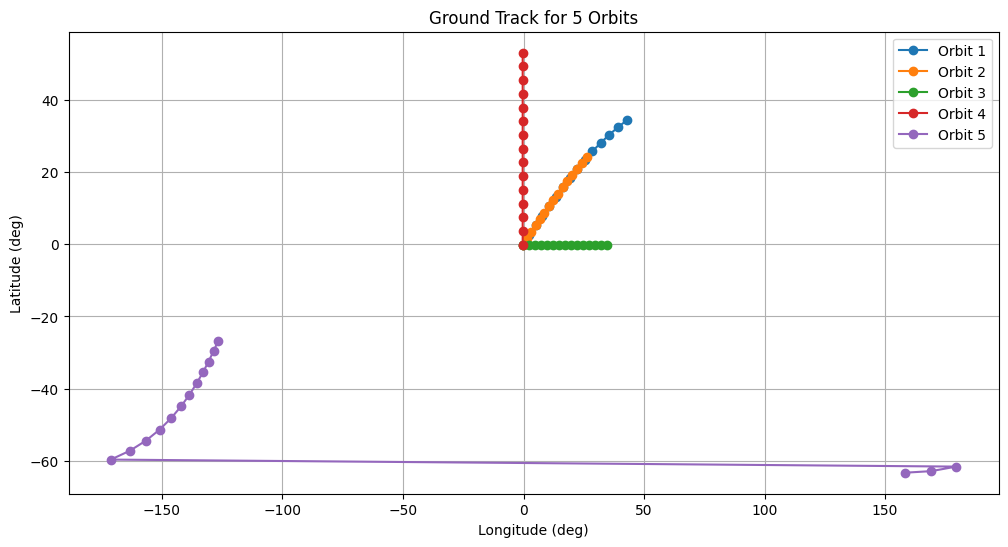

In [52]:
# ============================================================
# Cell 10: Plot Ground Track for the Five Orbits
# This cell plots the latitude and longitude ground tracks of
# the five satellites.
# ============================================================

plt.figure(figsize=(12, 6))

for name, gt in ground_tracks.items():
    plt.plot(gt["lon_deg"], gt["lat_deg"], marker="o", label=name)

plt.title("Ground Track for 5 Orbits")
plt.xlabel("Longitude (deg)")
plt.ylabel("Latitude (deg)")
plt.grid(True)
plt.legend()
plt.show()

In [53]:
# ============================================================
# Cell 11: Define Beni Suef Ground Station
# This cell defines the ground station location and converts it
# into Earth-centered coordinates.
# ============================================================

BENI_SUEF_LAT = 29.0661
BENI_SUEF_LON = 31.0994
EARTH_RADIUS = 6378.137  # km

def ground_station_ecef(lat_deg, lon_deg, alt_km=0):
    lat = np.radians(lat_deg)
    lon = np.radians(lon_deg)

    R = EARTH_RADIUS + alt_km

    x = R * np.cos(lat) * np.cos(lon)
    y = R * np.cos(lat) * np.sin(lon)
    z = R * np.sin(lat)

    return np.array([x, y, z])


station_pos = ground_station_ecef(BENI_SUEF_LAT, BENI_SUEF_LON)

print("Beni Suef Ground Station Position (km):")
print(station_pos)

Beni Suef Ground Station Position (km):
[4773.61063556 2879.55785842 3098.61576044]


In [54]:
# ============================================================
# Cell 12: Closest Pass Calculation
# This cell finds the closest satellite point to Beni Suef
# ground station for each orbit.
# ============================================================

closest_passes = []

for name, df in orbit_data.items():
    sat_pos = df[["x", "y", "z"]].values
    ranges = np.linalg.norm(sat_pos - station_pos, axis=1)

    min_idx = np.argmin(ranges)

    closest_passes.append({
        "Orbit": name,
        "Closest Time": df.loc[min_idx, "time"],
        "Minimum Range km": ranges[min_idx],
        "Latitude deg": df.loc[min_idx, "lat_deg"],
        "Longitude deg": df.loc[min_idx, "lon_deg"]
    })

closest_pass_df = pd.DataFrame(closest_passes)
closest_pass_df

,Orbit,Closest Time,Minimum Range km,Latitude deg,Longitude deg
0,Orbit 1,2026-04-25 09:11:00,521.120415,28.060225,31.982917
1,Orbit 2,2026-04-25 10:10:00,20054.518840,24.089732,26.366917
2,Orbit 3,2026-04-25 11:10:00,36729.339757,-0.125505,32.252824
3,Orbit 4,2026-04-25 09:09:00,3147.722000,34.048644,-0.336795
4,Orbit 5,2026-04-25 09:00:00,12118.366179,-63.264159,158.169950


In [55]:
# ============================================================
# Cell 13: Calculate Simple AER Data
# This cell calculates Azimuth, Elevation, and Range from the
# satellite to the Beni Suef ground station.
# ============================================================

def calculate_aer_simple(sat_pos, station_pos):
    rho = sat_pos - station_pos

    range_km = np.linalg.norm(rho)

    azimuth = np.degrees(np.arctan2(rho[1], rho[0]))
    if azimuth < 0:
        azimuth += 360

    elevation = np.degrees(np.arcsin(rho[2] / range_km))

    return azimuth, elevation, range_km


aer_data = {}

for name, df in orbit_data.items():
    aer_rows = []

    for _, row in df.iterrows():
        sat_pos = row[["x", "y", "z"]].values
        az, el, rng = calculate_aer_simple(sat_pos, station_pos)

        aer_rows.append({
            "time": row["time"],
            "azimuth_deg": az,
            "elevation_deg": el,
            "range_km": rng
        })

    aer_data[name] = pd.DataFrame(aer_rows)

    print(f"\n{name} AER:")
    display(aer_data[name].head())


Orbit 1 AER:


,time,azimuth_deg,elevation_deg,range_km
0,2026-04-25 09:00:00,305.777483,-40.884836,4761.020332
1,2026-04-25 09:01:00,308.848059,-39.945762,4350.157332
2,2026-04-25 09:02:00,312.000760,-38.901698,3935.137684
3,2026-04-25 09:03:00,315.283384,-37.732964,3516.648121
4,2026-04-25 09:04:00,318.769795,-36.406734,3095.505161



Orbit 2 AER:


,time,azimuth_deg,elevation_deg,range_km
0,2026-04-25 09:00:00,352.001949,-8.258152,22044.771969
1,2026-04-25 09:05:00,354.151578,-6.160181,21824.150061
2,2026-04-25 09:10:00,356.309385,-4.030012,21613.042548
3,2026-04-25 09:15:00,358.480539,-1.870911,21412.149351
4,2026-04-25 09:20:00,0.670397,0.313545,21222.158562



Orbit 3 AER:


,time,azimuth_deg,elevation_deg,range_km
0,2026-04-25 09:00:00,355.216565,-4.885271,37657.133535
1,2026-04-25 09:10:00,358.031229,-4.903207,37519.566087
2,2026-04-25 09:20:00,0.857046,-4.919636,37392.008721
3,2026-04-25 09:30:00,3.693264,-4.934484,37274.809569
4,2026-04-25 09:40:00,6.539078,-4.947681,37168.291966



Orbit 4 AER:


,time,azimuth_deg,elevation_deg,range_km
0,2026-04-25 09:00:00,305.777483,-40.884836,4761.020332
1,2026-04-25 09:01:00,305.597936,-36.531777,4469.343196
2,2026-04-25 09:02:00,305.024067,-31.751891,4193.057688
3,2026-04-25 09:03:00,304.041444,-26.500356,3936.743324
4,2026-04-25 09:04:00,302.625753,-20.743168,3705.783933



Orbit 5 AER:


,time,azimuth_deg,elevation_deg,range_km
0,2026-04-25 09:00:00,192.741429,-49.693553,12118.366179
1,2026-04-25 09:01:00,196.234233,-48.403517,12338.605318
2,2026-04-25 09:02:00,199.474739,-47.022563,12556.075655
3,2026-04-25 09:03:00,202.474860,-45.568524,12770.162110
4,2026-04-25 09:04:00,205.249302,-44.057623,12980.420902


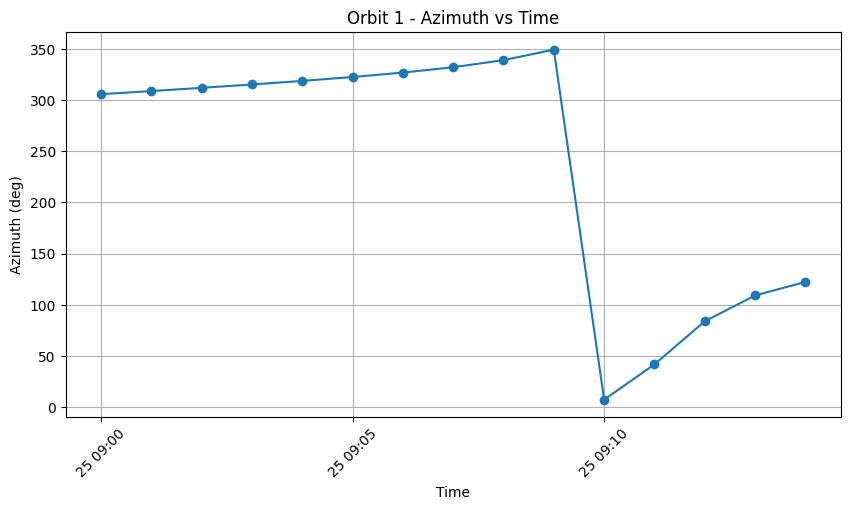

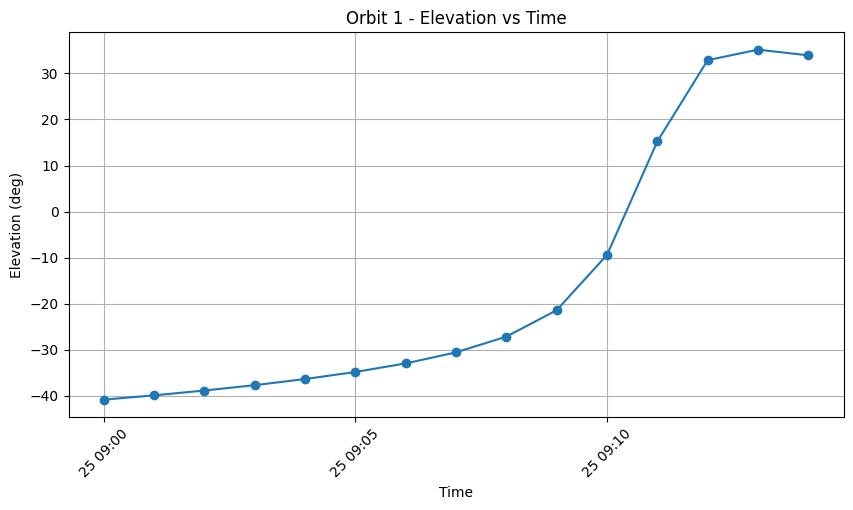

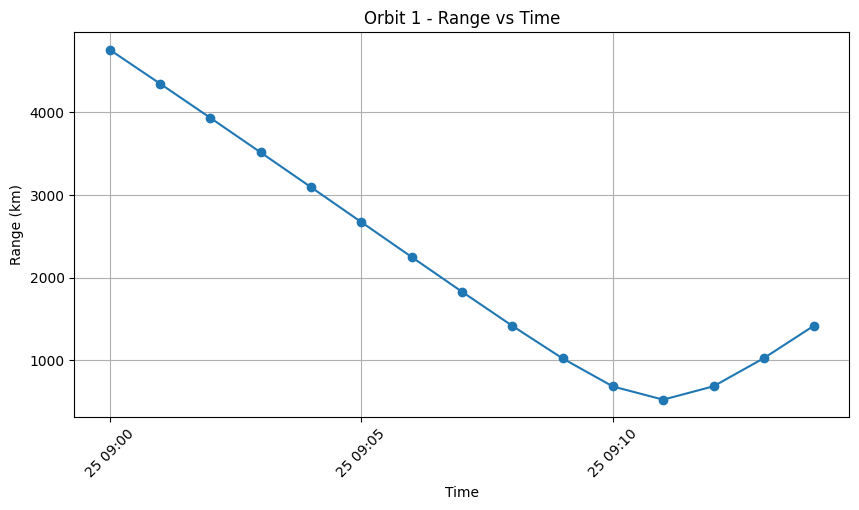

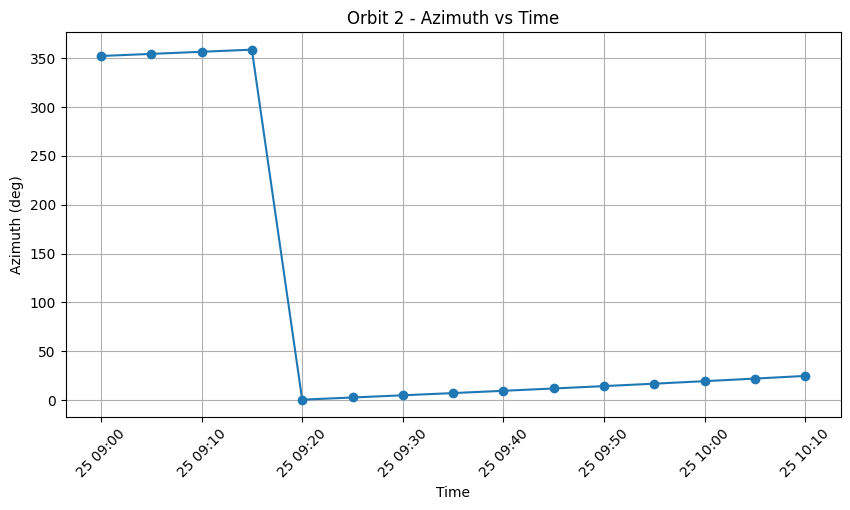

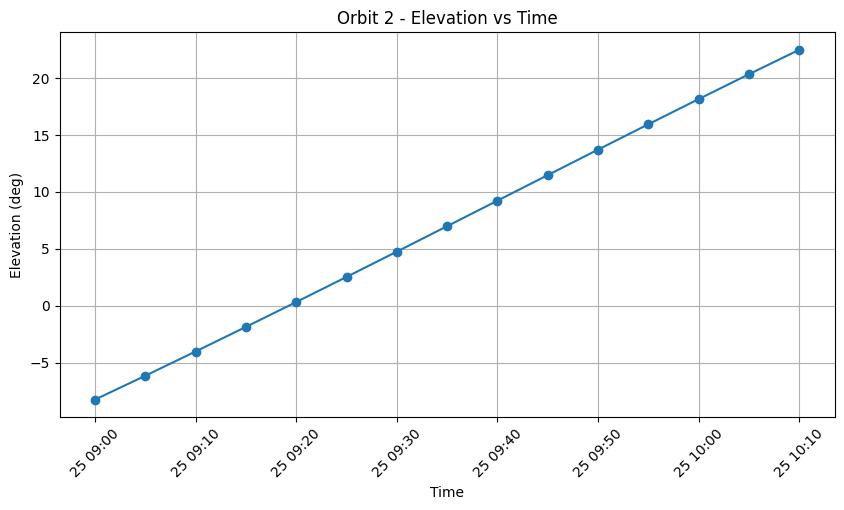

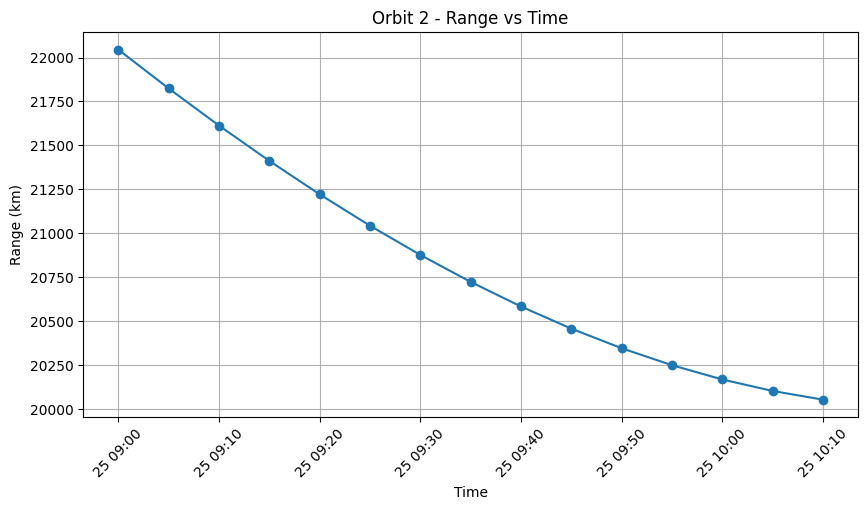

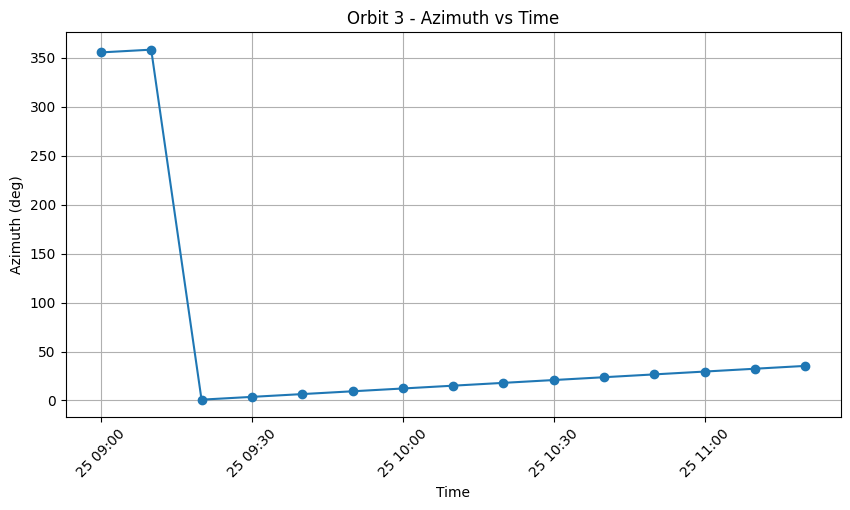

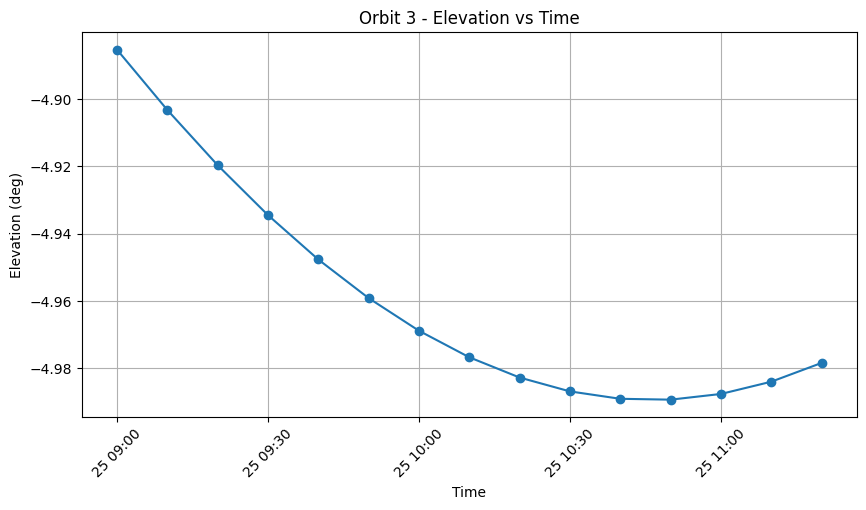

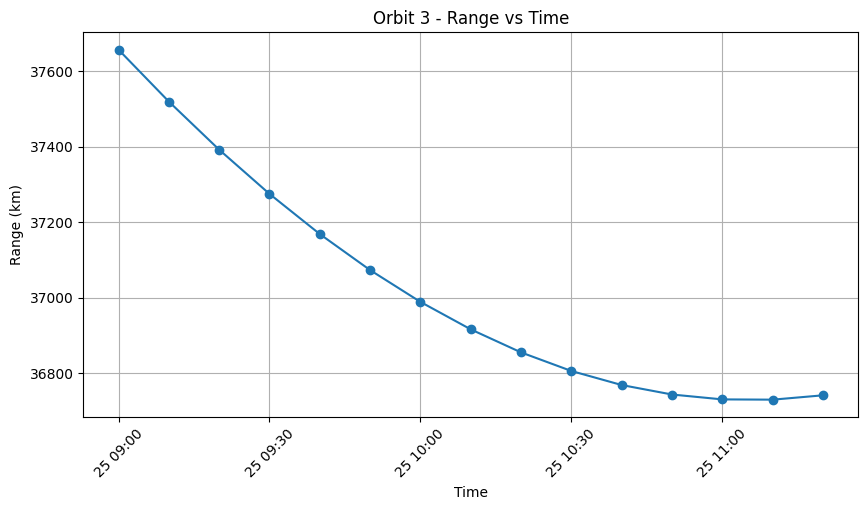

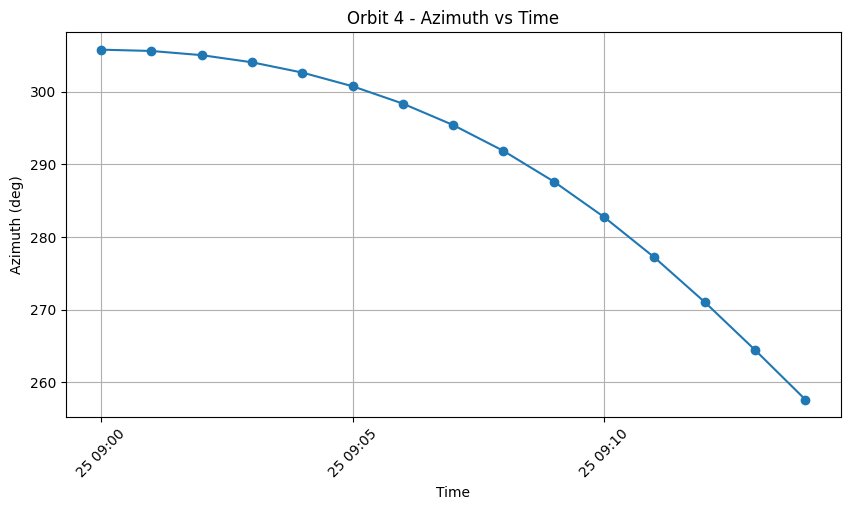

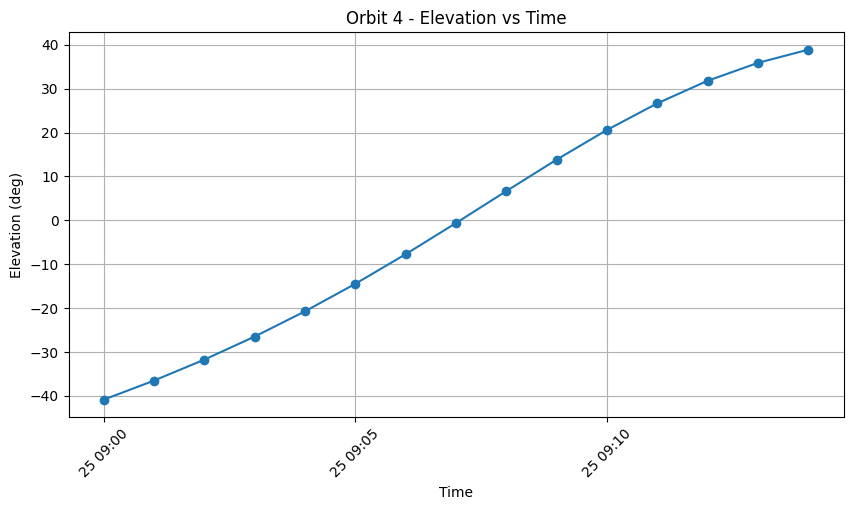

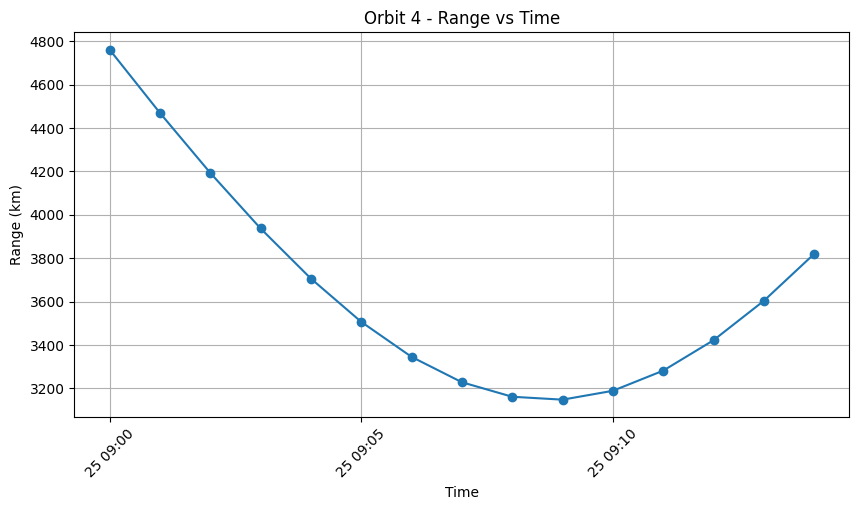

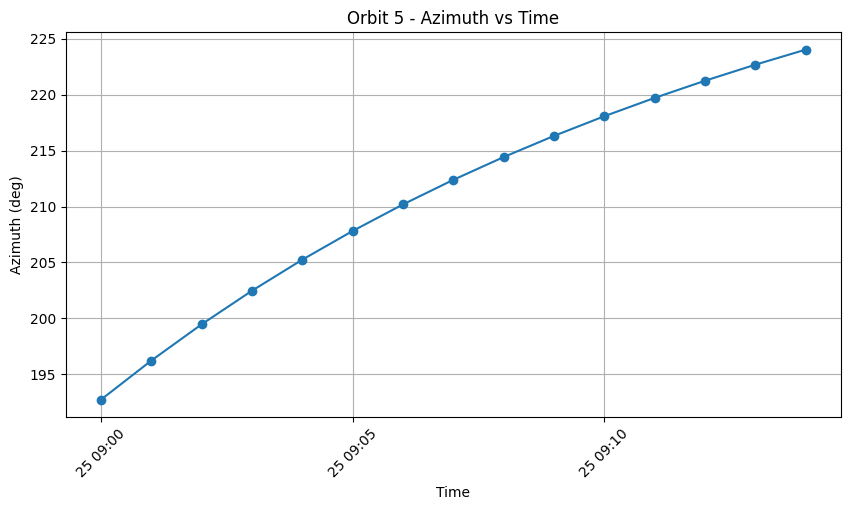

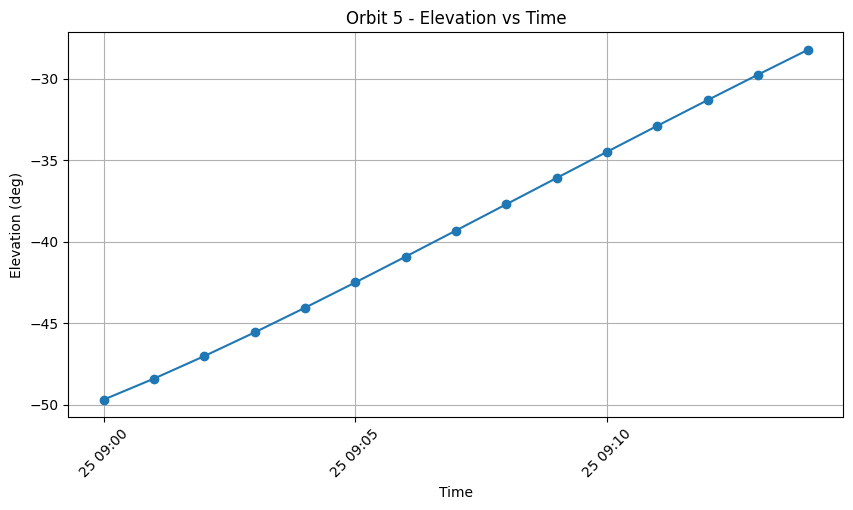

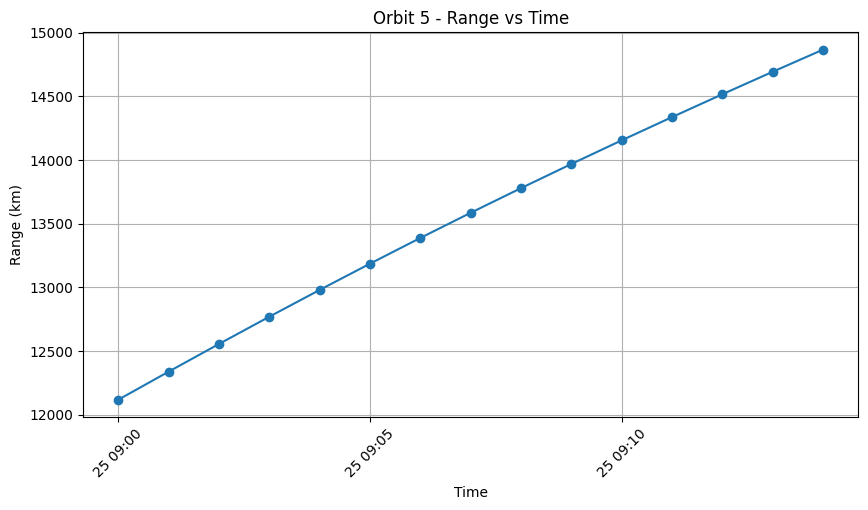

In [56]:
# ============================================================
# Cell 14: Plot AER Data
# This cell plots Azimuth, Elevation, and Range versus time for
# each orbit.
# ============================================================

for name, aer in aer_data.items():
    plt.figure(figsize=(10, 5))
    plt.plot(aer["time"], aer["azimuth_deg"], marker="o")
    plt.title(f"{name} - Azimuth vs Time")
    plt.xlabel("Time")
    plt.ylabel("Azimuth (deg)")
    plt.grid(True)
    plt.xticks(rotation=45)
    plt.show()

    plt.figure(figsize=(10, 5))
    plt.plot(aer["time"], aer["elevation_deg"], marker="o")
    plt.title(f"{name} - Elevation vs Time")
    plt.xlabel("Time")
    plt.ylabel("Elevation (deg)")
    plt.grid(True)
    plt.xticks(rotation=45)
    plt.show()

    plt.figure(figsize=(10, 5))
    plt.plot(aer["time"], aer["range_km"], marker="o")
    plt.title(f"{name} - Range vs Time")
    plt.xlabel("Time")
    plt.ylabel("Range (km)")
    plt.grid(True)
    plt.xticks(rotation=45)
    plt.show()

In [57]:
# ============================================================
# Cell 15: Stronger Error Analysis
# This cell calculates mean error, maximum error, minimum error,
# RMSE, and percentage error for each orbit.
# ============================================================

error_summary = []

for name, df in orbit_data.items():
    actual_pos = results[name]["actual"]
    predicted_pos = results[name]["pred"]

    position_errors = np.linalg.norm(predicted_pos - actual_pos, axis=1)

    mean_error = np.mean(position_errors)
    max_error = np.max(position_errors)
    min_error = np.min(position_errors)
    rmse = results[name]["rmse"]

    orbit_radius_mean = np.mean(np.linalg.norm(actual_pos, axis=1))
    percentage_error = (mean_error / orbit_radius_mean) * 100

    error_summary.append({
        "Orbit": name,
        "Mean Position Error km": mean_error,
        "Max Position Error km": max_error,
        "Min Position Error km": min_error,
        "RMSE km": rmse,
        "Percentage Error %": percentage_error
    })

error_summary_df = pd.DataFrame(error_summary)
error_summary_df

,Orbit,Mean Position Error km,Max Position Error km,Min Position Error km,RMSE km,Percentage Error %
0,Orbit 1,118.613111,256.260043,0.0,142.326167,1.724495
1,Orbit 2,191.730291,401.592184,0.0,227.940307,0.726853
2,Orbit 3,299.685313,627.160890,0.0,356.194161,0.710759
3,Orbit 4,122.313555,265.892951,0.0,147.131137,1.778295
4,Orbit 5,116.922637,245.277221,0.0,139.398873,1.548723


In [58]:
# ============================================================
# Cell 16: Estimate Velocity from Two STK Points
# This cell estimates satellite velocity using only two selected
# STK position points and their timestamps.
# ============================================================

def estimate_velocity_from_two_points(p1, p2):
    r1 = p1[["x", "y", "z"]].values.astype(float)
    r2 = p2[["x", "y", "z"]].values.astype(float)

    t1 = p1["t_sec"]
    t2 = p2["t_sec"]

    dt = t2 - t1

    if dt == 0:
        raise ValueError("The two points have the same time. Cannot estimate velocity.")

    v_est = (r2 - r1) / dt
    return r1, v_est, dt


two_point_results = []

np.random.seed(42)

for name, df in orbit_data.items():
    idx = np.random.choice(df.index, size=2, replace=False)
    idx = sorted(idx)

    p1 = df.loc[idx[0]]
    p2 = df.loc[idx[1]]

    r_est, v_est, dt = estimate_velocity_from_two_points(p1, p2)

    elements_2points = orbital_elements_from_rv(r_est, v_est)

    two_point_results.append({
        "Orbit": name,
        "Point 1 index": idx[0],
        "Point 2 index": idx[1],
        "Delta Time sec": dt,
        "Estimated vx km/s": v_est[0],
        "Estimated vy km/s": v_est[1],
        "Estimated vz km/s": v_est[2],
        **elements_2points
    })

two_point_df = pd.DataFrame(two_point_results)
two_point_df

,Orbit,Point 1 index,Point 2 index,Delta Time sec,Estimated vx km/s,Estimated vy km/s,Estimated vz km/s,a_km,e,i_deg,RAAN_deg,arg_perigee_deg,true_anomaly_deg,rp_km,ra_km,direction
0,Orbit 1,9,11,120.0,-4.658432,4.263712,4.250549,6877.613138,0.066405,45.022004,359.798291,127.939625,266.126926,6420.908530,7334.317746,Prograde Inclined
1,Orbit 2,10,12,600.0,-1.795739,2.440031,2.433963,26363.465086,0.044202,44.999493,359.808178,118.377837,266.746110,25198.159223,27528.770949,Prograde Inclined
2,Orbit 3,1,12,6600.0,-0.837198,2.927954,0.002051,41377.503661,0.239056,0.147187,90.758308,19.628311,251.781713,31485.972712,51269.034610,Prograde / Near-equatorial
3,Orbit 4,2,7,300.0,-2.206176,0.013398,7.238462,6797.313195,0.165444,89.997182,359.661301,111.015577,256.436331,5672.740393,7921.885998,Polar
4,Orbit 5,8,10,120.0,-1.601895,-8.596301,3.436365,22992.663419,0.693860,63.264814,248.026899,274.390292,33.369402,7038.970569,38946.356269,Prograde Inclined


In [59]:
# ============================================================
# Cell 17: Automatic Orbit Classification
# This cell classifies each orbit as LEO, MEO, GEO, Polar,
# Highly Elliptical, or Other.
# ============================================================

def classify_orbit(a_km, e, i_deg):
    earth_radius = 6378.137
    altitude = a_km - earth_radius

    if e > 0.5:
        return "Highly Elliptical Orbit"

    if abs(i_deg - 90) <= 10:
        return "Polar Orbit"

    if 35000 <= altitude <= 37000 and i_deg < 10:
        return "GEO Orbit"

    if altitude < 2000:
        return "LEO Orbit"

    if 2000 <= altitude < 35000:
        return "MEO Orbit"

    return "Other Orbit"


two_point_df["Orbit Type"] = two_point_df.apply(
    lambda row: classify_orbit(row["a_km"], row["e"], row["i_deg"]),
    axis=1
)

two_point_df[
    [
        "Orbit",
        "Orbit Type",
        "a_km",
        "e",
        "i_deg",
        "RAAN_deg",
        "arg_perigee_deg",
        "true_anomaly_deg",
        "direction"
    ]
]

,Orbit,Orbit Type,a_km,e,i_deg,RAAN_deg,arg_perigee_deg,true_anomaly_deg,direction
0,Orbit 1,LEO Orbit,6877.613138,0.066405,45.022004,359.798291,127.939625,266.126926,Prograde Inclined
1,Orbit 2,MEO Orbit,26363.465086,0.044202,44.999493,359.808178,118.377837,266.746110,Prograde Inclined
2,Orbit 3,MEO Orbit,41377.503661,0.239056,0.147187,90.758308,19.628311,251.781713,Prograde / Near-equatorial
3,Orbit 4,Polar Orbit,6797.313195,0.165444,89.997182,359.661301,111.015577,256.436331,Polar
4,Orbit 5,Highly Elliptical Orbit,22992.663419,0.693860,63.264814,248.026899,274.390292,33.369402,Prograde Inclined


In [60]:
# ============================================================
# Cell 18: Best Pass Selection from Beni Suef
# This cell selects the best satellite pass based on maximum
# elevation, minimum range, and visibility points.
# ============================================================

best_pass_rows = []

for name, aer in aer_data.items():
    max_elevation = aer["elevation_deg"].max()
    min_range = aer["range_km"].min()

    visible_points = aer[aer["elevation_deg"] > 0]
    visibility_count = len(visible_points)

    visibility_duration_sec = visibility_count * 60 if visibility_count > 0 else 0

    best_idx = aer["elevation_deg"].idxmax()

    best_pass_rows.append({
        "Orbit": name,
        "Best Time": aer.loc[best_idx, "time"],
        "Max Elevation deg": max_elevation,
        "Minimum Range km": min_range,
        "Visible Points": visibility_count,
        "Estimated Visibility Duration sec": visibility_duration_sec,
        "Tracking Score": (max_elevation * 2) - (min_range / 1000) + (visibility_count * 0.5)
    })

best_pass_df = pd.DataFrame(best_pass_rows)

best_pass_df = best_pass_df.sort_values(
    by="Tracking Score",
    ascending=False
).reset_index(drop=True)

best_pass_df

,Orbit,Best Time,Max Elevation deg,Minimum Range km,Visible Points,Estimated Visibility Duration sec,Tracking Score
0,Orbit 4,2026-04-25 09:14:00,38.886197,3147.722000,7,420,78.124673
1,Orbit 1,2026-04-25 09:13:00,35.174008,521.120415,4,240,71.826895
2,Orbit 2,2026-04-25 10:10:00,22.480005,20054.518840,11,660,30.405491
3,Orbit 3,2026-04-25 09:00:00,-4.885271,36729.339757,0,0,-46.499882
4,Orbit 5,2026-04-25 09:14:00,-28.223971,12118.366179,0,0,-68.566308


In [61]:
# ============================================================
# Cell 19: Select the Best Orbit to Track
# This cell prints the best recommended orbit/pass for tracking
# from the Beni Suef ground station.
# ============================================================

best_orbit = best_pass_df.iloc[0]

print("Best Orbit to Track from Beni Suef Ground Station")
print("--------------------------------------------------")
print(f"Orbit: {best_orbit['Orbit']}")
print(f"Best Time: {best_orbit['Best Time']}")
print(f"Max Elevation: {best_orbit['Max Elevation deg']:.2f} deg")
print(f"Minimum Range: {best_orbit['Minimum Range km']:.2f} km")
print(f"Visibility Duration: {best_orbit['Estimated Visibility Duration sec']} sec")
print(f"Tracking Score: {best_orbit['Tracking Score']:.2f}")

Best Orbit to Track from Beni Suef Ground Station
--------------------------------------------------
Orbit: Orbit 4
Best Time: 2026-04-25 09:14:00
Max Elevation: 38.89 deg
Minimum Range: 3147.72 km
Visibility Duration: 420 sec
Tracking Score: 78.12


In [62]:
# ============================================================
# Cell 20: Best Two Points Auto Selection
# This cell tests all possible pairs from the first 15 STK points
# and selects the best pair that gives the lowest prediction error.
# ============================================================

def evaluate_two_points_pair(df, idx1, idx2):
    p1 = df.loc[idx1]
    p2 = df.loc[idx2]

    r_est, v_est, dt = estimate_velocity_from_two_points(p1, p2)

    times = df["t_sec"].values
    pred = propagate_orbit(r_est, v_est, times)
    actual = df[["x", "y", "z"]].values

    errors = np.linalg.norm(pred - actual, axis=1)
    rmse = np.sqrt(np.mean(errors**2))

    return rmse, r_est, v_est, dt


best_two_points_rows = []

for name, df in orbit_data.items():
    candidate_indices = list(df.index[:15])
    best_rmse = np.inf
    best_pair = None
    best_dt = None
    best_r = None
    best_v = None

    for idx1, idx2 in combinations(candidate_indices, 2):
        try:
            rmse, r_est, v_est, dt = evaluate_two_points_pair(df, idx1, idx2)

            if rmse < best_rmse:
                best_rmse = rmse
                best_pair = (idx1, idx2)
                best_dt = dt
                best_r = r_est
                best_v = v_est

        except:
            continue

    elements_best = orbital_elements_from_rv(best_r, best_v)
    orbit_type = classify_orbit(elements_best["a_km"], elements_best["e"], elements_best["i_deg"])

    best_two_points_rows.append({
        "Orbit": name,
        "Best Point 1": best_pair[0],
        "Best Point 2": best_pair[1],
        "Delta Time sec": best_dt,
        "Best RMSE km": best_rmse,
        "Orbit Type": orbit_type,
        "Estimated vx km/s": best_v[0],
        "Estimated vy km/s": best_v[1],
        "Estimated vz km/s": best_v[2],
        **elements_best
    })

best_two_points_df = pd.DataFrame(best_two_points_rows)
best_two_points_df

,Orbit,Best Point 1,Best Point 2,Delta Time sec,Best RMSE km,Orbit Type,Estimated vx km/s,Estimated vy km/s,Estimated vz km/s,a_km,e,i_deg,RAAN_deg,arg_perigee_deg,true_anomaly_deg,rp_km,ra_km,direction
0,Orbit 1,0,1,60.0,286.861595,LEO Orbit,-0.207387,5.380555,5.386839,6885.220221,0.033236,45.037296,359.808263,89.923008,269.869011,6656.379694,7114.060749,Prograde Inclined
1,Orbit 2,0,1,300.0,456.234323,MEO Orbit,-0.062619,2.748386,2.748170,26376.344658,0.022105,45.000089,359.808454,91.234570,268.557314,25793.307977,26959.381340,Prograde Inclined
2,Orbit 3,0,1,600.0,713.100634,GEO Orbit,-0.049089,3.074253,0.000022,42163.677784,0.021876,0.147187,90.758308,0.185024,268.717965,41241.294346,43086.061221,Prograde / Near-equatorial
3,Orbit 4,0,1,60.0,292.401620,Polar Orbit,-0.232450,0.001748,7.597041,6856.516741,0.033301,89.997182,359.661301,97.183107,262.669732,6628.190786,7084.842696,Polar
4,Orbit 5,0,1,60.0,278.809141,Highly Elliptical Orbit,-3.645019,-9.351588,0.235398,26380.217261,0.739463,63.264229,248.028468,273.452937,356.610712,6873.022690,45887.411832,Prograde Inclined


In [63]:
# ============================================================
# Cell 21: Compare Initial Prediction vs Best Two Points Prediction
# This cell compares the RMSE from the initial prediction with
# the RMSE from the best selected pair of points.
# ============================================================

comparison_rows = []

for name in best_two_points_df["Orbit"]:
    initial_rmse = results[name]["rmse"]

    best_rmse = best_two_points_df.loc[
        best_two_points_df["Orbit"] == name,
        "Best RMSE km"
    ].values[0]

    improvement = ((initial_rmse - best_rmse) / initial_rmse) * 100

    comparison_rows.append({
        "Orbit": name,
        "Initial RMSE km": initial_rmse,
        "Best 2 Points RMSE km": best_rmse,
        "Improvement %": improvement
    })

comparison_df = pd.DataFrame(comparison_rows)
comparison_df

,Orbit,Initial RMSE km,Best 2 Points RMSE km,Improvement %
0,Orbit 1,142.326167,286.861595,-101.552252
1,Orbit 2,227.940307,456.234323,-100.155176
2,Orbit 3,356.194161,713.100634,-100.199978
3,Orbit 4,147.131137,292.401620,-98.735378
4,Orbit 5,139.398873,278.809141,-100.008174


In [64]:
# ============================================================
# Cell 22: Generate Telescope Tracking Commands
# This cell calculates azimuth, elevation, azimuth rate, and
# elevation rate as tracking commands for telescope/motor control.
# ============================================================

tracking_commands = {}

for name, aer in aer_data.items():
    cmd = aer.copy()

    cmd["azimuth_rate_deg_per_sec"] = cmd["azimuth_deg"].diff() / cmd["time"].diff().dt.total_seconds()
    cmd["elevation_rate_deg_per_sec"] = cmd["elevation_deg"].diff() / cmd["time"].diff().dt.total_seconds()

    cmd["azimuth_rate_deg_per_sec"] = cmd["azimuth_rate_deg_per_sec"].fillna(0)
    cmd["elevation_rate_deg_per_sec"] = cmd["elevation_rate_deg_per_sec"].fillna(0)

    tracking_commands[name] = cmd

    print(f"\n{name} Tracking Commands:")
    display(cmd.head())


Orbit 1 Tracking Commands:


,time,azimuth_deg,elevation_deg,range_km,azimuth_rate_deg_per_sec,elevation_rate_deg_per_sec
0,2026-04-25 09:00:00,305.777483,-40.884836,4761.020332,0.000000,0.000000
1,2026-04-25 09:01:00,308.848059,-39.945762,4350.157332,0.051176,0.015651
2,2026-04-25 09:02:00,312.000760,-38.901698,3935.137684,0.052545,0.017401
3,2026-04-25 09:03:00,315.283384,-37.732964,3516.648121,0.054710,0.019479
4,2026-04-25 09:04:00,318.769795,-36.406734,3095.505161,0.058107,0.022104



Orbit 2 Tracking Commands:


,time,azimuth_deg,elevation_deg,range_km,azimuth_rate_deg_per_sec,elevation_rate_deg_per_sec
0,2026-04-25 09:00:00,352.001949,-8.258152,22044.771969,0.000000,0.000000
1,2026-04-25 09:05:00,354.151578,-6.160181,21824.150061,0.007165,0.006993
2,2026-04-25 09:10:00,356.309385,-4.030012,21613.042548,0.007193,0.007101
3,2026-04-25 09:15:00,358.480539,-1.870911,21412.149351,0.007237,0.007197
4,2026-04-25 09:20:00,0.670397,0.313545,21222.158562,-1.192700,0.007282



Orbit 3 Tracking Commands:


,time,azimuth_deg,elevation_deg,range_km,azimuth_rate_deg_per_sec,elevation_rate_deg_per_sec
0,2026-04-25 09:00:00,355.216565,-4.885271,37657.133535,0.000000,0.000000
1,2026-04-25 09:10:00,358.031229,-4.903207,37519.566087,0.004691,-0.000030
2,2026-04-25 09:20:00,0.857046,-4.919636,37392.008721,-0.595290,-0.000027
3,2026-04-25 09:30:00,3.693264,-4.934484,37274.809569,0.004727,-0.000025
4,2026-04-25 09:40:00,6.539078,-4.947681,37168.291966,0.004743,-0.000022



Orbit 4 Tracking Commands:


,time,azimuth_deg,elevation_deg,range_km,azimuth_rate_deg_per_sec,elevation_rate_deg_per_sec
0,2026-04-25 09:00:00,305.777483,-40.884836,4761.020332,0.000000,0.000000
1,2026-04-25 09:01:00,305.597936,-36.531777,4469.343196,-0.002992,0.072551
2,2026-04-25 09:02:00,305.024067,-31.751891,4193.057688,-0.009564,0.079665
3,2026-04-25 09:03:00,304.041444,-26.500356,3936.743324,-0.016377,0.087526
4,2026-04-25 09:04:00,302.625753,-20.743168,3705.783933,-0.023595,0.095953



Orbit 5 Tracking Commands:


,time,azimuth_deg,elevation_deg,range_km,azimuth_rate_deg_per_sec,elevation_rate_deg_per_sec
0,2026-04-25 09:00:00,192.741429,-49.693553,12118.366179,0.000000,0.000000
1,2026-04-25 09:01:00,196.234233,-48.403517,12338.605318,0.058213,0.021501
2,2026-04-25 09:02:00,199.474739,-47.022563,12556.075655,0.054008,0.023016
3,2026-04-25 09:03:00,202.474860,-45.568524,12770.162110,0.050002,0.024234
4,2026-04-25 09:04:00,205.249302,-44.057623,12980.420902,0.046241,0.025182


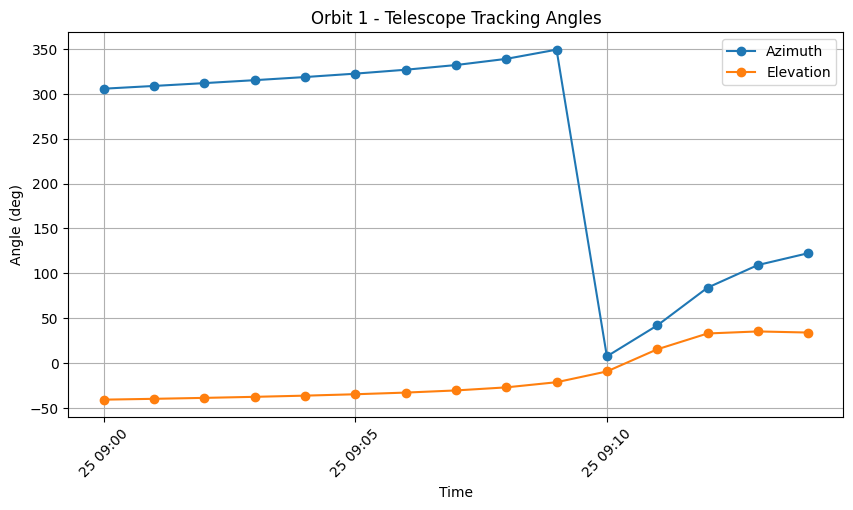

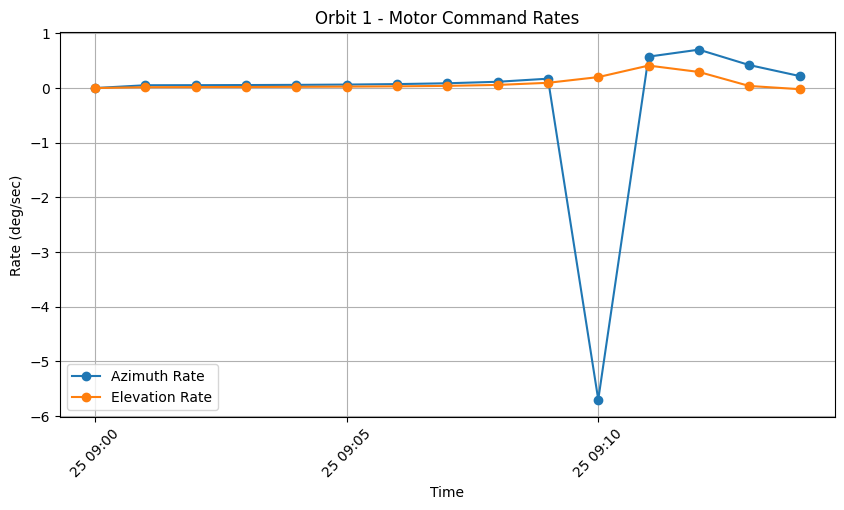

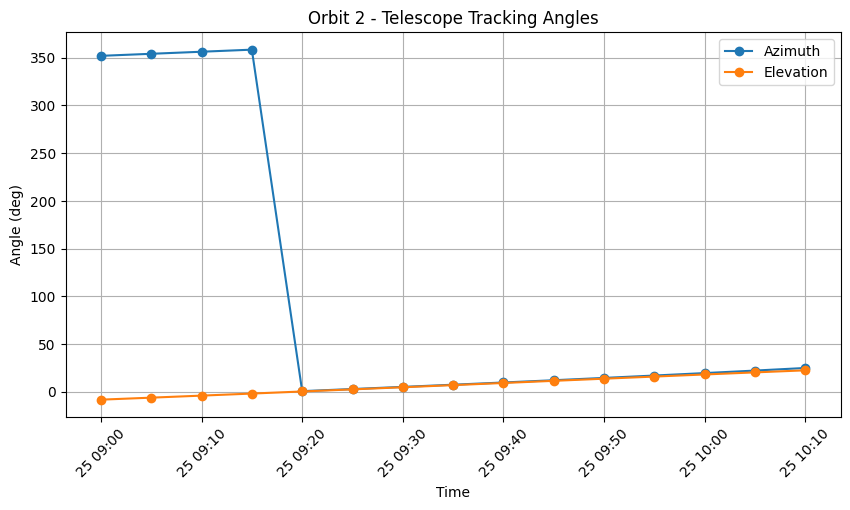

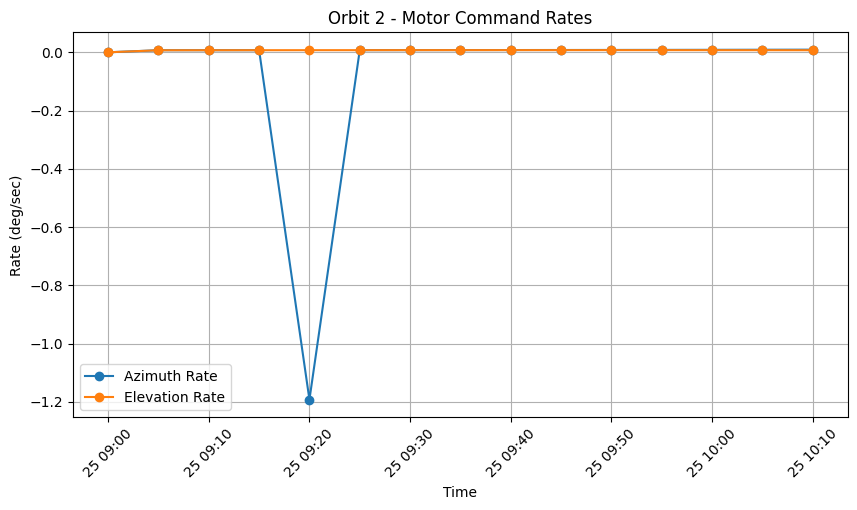

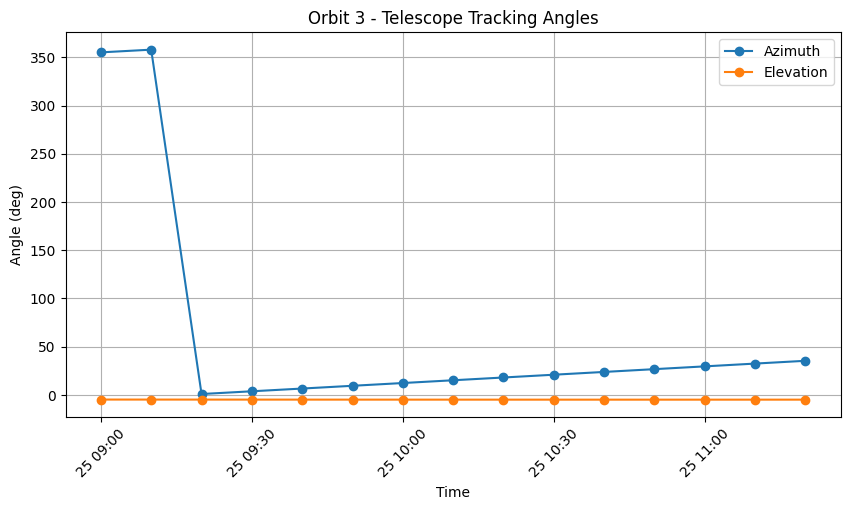

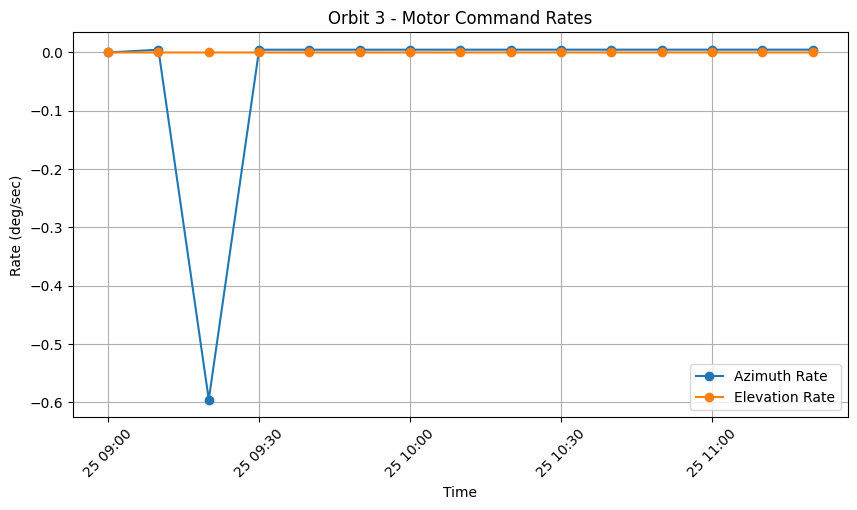

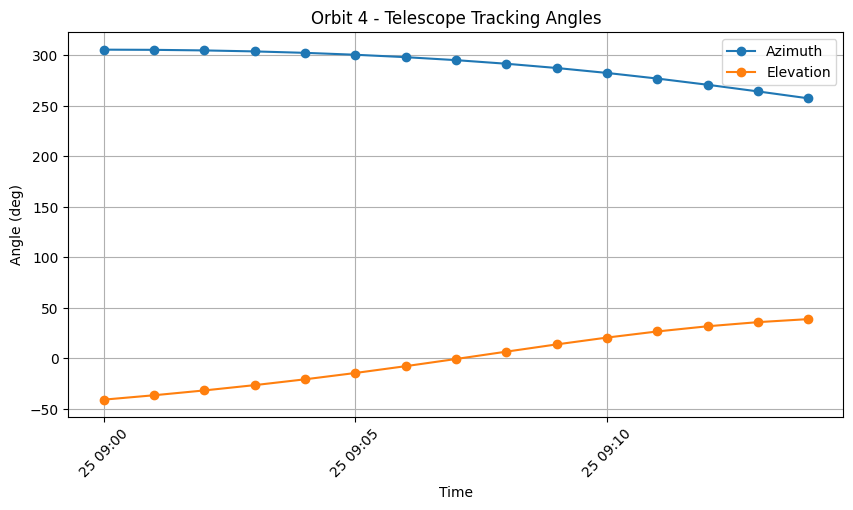

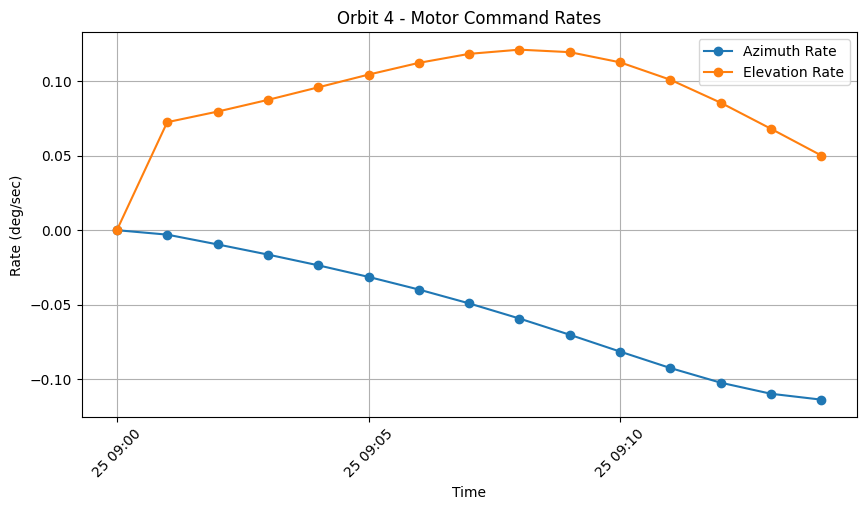

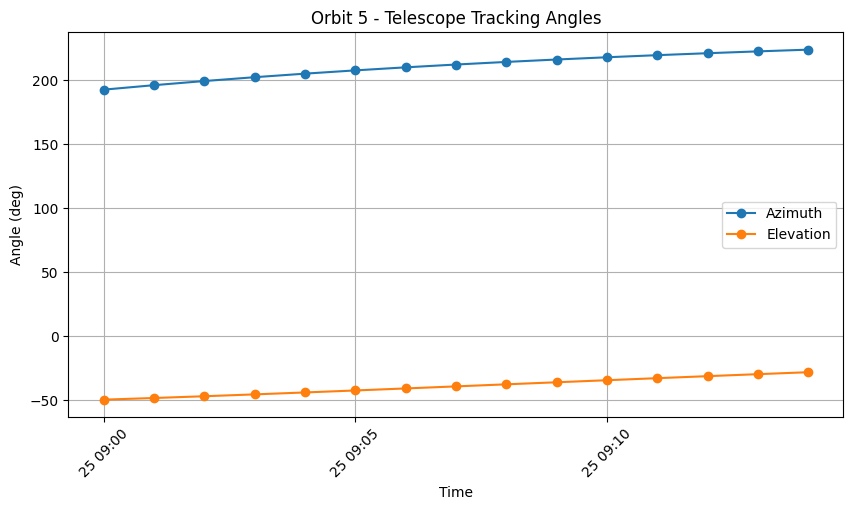

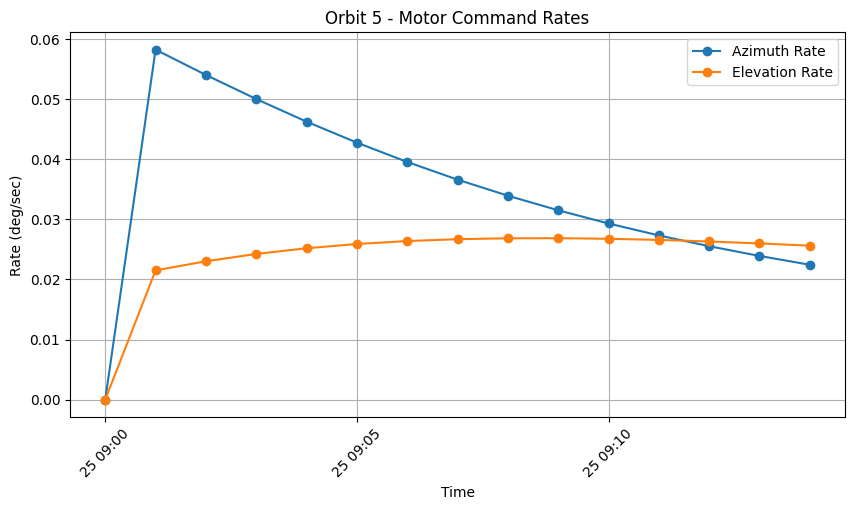

In [65]:
# ============================================================
# Cell 23: Plot Telescope Tracking Commands
# This cell plots pointing angles and angular rates required
# for autonomous telescope tracking.
# ============================================================

for name, cmd in tracking_commands.items():
    plt.figure(figsize=(10, 5))
    plt.plot(cmd["time"], cmd["azimuth_deg"], marker="o", label="Azimuth")
    plt.plot(cmd["time"], cmd["elevation_deg"], marker="o", label="Elevation")
    plt.title(f"{name} - Telescope Tracking Angles")
    plt.xlabel("Time")
    plt.ylabel("Angle (deg)")
    plt.grid(True)
    plt.legend()
    plt.xticks(rotation=45)
    plt.show()

    plt.figure(figsize=(10, 5))
    plt.plot(cmd["time"], cmd["azimuth_rate_deg_per_sec"], marker="o", label="Azimuth Rate")
    plt.plot(cmd["time"], cmd["elevation_rate_deg_per_sec"], marker="o", label="Elevation Rate")
    plt.title(f"{name} - Motor Command Rates")
    plt.xlabel("Time")
    plt.ylabel("Rate (deg/sec)")
    plt.grid(True)
    plt.legend()
    plt.xticks(rotation=45)
    plt.show()

In [66]:
# ============================================================
# Cell 24: Pass Visibility Window AOS / LOS
# This cell determines the Acquisition of Signal, Closest Approach,
# Maximum Elevation, and Loss of Signal for each orbit.
# ============================================================

visibility_windows = []

for name, aer in aer_data.items():
    visible = aer[aer["elevation_deg"] > 0].copy()

    if len(visible) > 0:
        aos_time = visible["time"].iloc[0]
        los_time = visible["time"].iloc[-1]

        closest_idx = visible["range_km"].idxmin()
        closest_time = aer.loc[closest_idx, "time"]

        max_el_idx = visible["elevation_deg"].idxmax()
        max_el_time = aer.loc[max_el_idx, "time"]

        duration_sec = (los_time - aos_time).total_seconds()

        visibility_windows.append({
            "Orbit": name,
            "AOS Time": aos_time,
            "Closest Approach Time": closest_time,
            "Max Elevation Time": max_el_time,
            "LOS Time": los_time,
            "Visibility Duration sec": duration_sec,
            "Max Elevation deg": visible["elevation_deg"].max(),
            "Minimum Range km": visible["range_km"].min()
        })

    else:
        visibility_windows.append({
            "Orbit": name,
            "AOS Time": None,
            "Closest Approach Time": None,
            "Max Elevation Time": None,
            "LOS Time": None,
            "Visibility Duration sec": 0,
            "Max Elevation deg": aer["elevation_deg"].max(),
            "Minimum Range km": aer["range_km"].min()
        })

visibility_window_df = pd.DataFrame(visibility_windows)
visibility_window_df

,Orbit,AOS Time,Closest Approach Time,Max Elevation Time,LOS Time,Visibility Duration sec,Max Elevation deg,Minimum Range km
0,Orbit 1,2026-04-25 09:11:00,2026-04-25 09:11:00,2026-04-25 09:13:00,2026-04-25 09:14:00,180.0,35.174008,521.120415
1,Orbit 2,2026-04-25 09:20:00,2026-04-25 10:10:00,2026-04-25 10:10:00,2026-04-25 10:10:00,3000.0,22.480005,20054.518840
2,Orbit 3,NaT,NaT,NaT,NaT,0.0,-4.885271,36729.339757
3,Orbit 4,2026-04-25 09:08:00,2026-04-25 09:09:00,2026-04-25 09:14:00,2026-04-25 09:14:00,360.0,38.886197,3147.722000
4,Orbit 5,NaT,NaT,NaT,NaT,0.0,-28.223971,12118.366179


In [67]:
# ============================================================
# Cell 25: Final Autonomous Tracking Decision
# This cell ranks all orbits based on visibility duration,
# maximum elevation, and tracking score.
# ============================================================

tracking_decision_df = visibility_window_df.merge(
    best_pass_df[["Orbit", "Tracking Score"]],
    on="Orbit",
    how="left"
)

tracking_decision_df = tracking_decision_df.sort_values(
    by=["Visibility Duration sec", "Max Elevation deg", "Tracking Score"],
    ascending=False
).reset_index(drop=True)

tracking_decision_df

,Orbit,AOS Time,Closest Approach Time,Max Elevation Time,LOS Time,Visibility Duration sec,Max Elevation deg,Minimum Range km,Tracking Score
0,Orbit 2,2026-04-25 09:20:00,2026-04-25 10:10:00,2026-04-25 10:10:00,2026-04-25 10:10:00,3000.0,22.480005,20054.518840,30.405491
1,Orbit 4,2026-04-25 09:08:00,2026-04-25 09:09:00,2026-04-25 09:14:00,2026-04-25 09:14:00,360.0,38.886197,3147.722000,78.124673
2,Orbit 1,2026-04-25 09:11:00,2026-04-25 09:11:00,2026-04-25 09:13:00,2026-04-25 09:14:00,180.0,35.174008,521.120415,71.826895
3,Orbit 3,NaT,NaT,NaT,NaT,0.0,-4.885271,36729.339757,-46.499882
4,Orbit 5,NaT,NaT,NaT,NaT,0.0,-28.223971,12118.366179,-68.566308


In [68]:
# ============================================================
# Cell 26: RK4 Orbit Propagator
# This cell implements a fourth-order Runge-Kutta method for
# more accurate two-body orbital propagation.
# ============================================================

def two_body_derivatives(state, mu=MU):
    r = state[:3]
    v = state[3:]

    r_norm = np.linalg.norm(r)
    a = -mu * r / r_norm**3

    return np.hstack((v, a))


def rk4_step(state, dt, mu=MU):
    k1 = two_body_derivatives(state, mu)
    k2 = two_body_derivatives(state + 0.5 * dt * k1, mu)
    k3 = two_body_derivatives(state + 0.5 * dt * k2, mu)
    k4 = two_body_derivatives(state + dt * k3, mu)

    return state + (dt / 6.0) * (k1 + 2*k2 + 2*k3 + k4)


def propagate_orbit_rk4(r0, v0, times):
    state = np.hstack((r0, v0)).astype(float)

    predicted = []
    last_t = times[0]

    for t in times:
        dt = t - last_t

        if dt != 0:
            state = rk4_step(state, dt)

        predicted.append(state[:3].copy())
        last_t = t

    return np.array(predicted)

In [69]:
# ============================================================
# Cell 27: Compare Euler Propagation with RK4 Propagation
# This cell compares prediction accuracy between the simple
# Euler method and the more accurate RK4 method.
# ============================================================

rk4_results = {}

for name, df in orbit_data.items():
    r0 = df.loc[0, ["x", "y", "z"]].values.astype(float)
    v0 = df.loc[0, ["vx", "vy", "vz"]].values.astype(float)
    times = df["t_sec"].values

    pred_rk4 = propagate_orbit_rk4(r0, v0, times)
    actual = df[["x", "y", "z"]].values

    errors_rk4 = np.linalg.norm(pred_rk4 - actual, axis=1)
    rmse_rk4 = np.sqrt(np.mean(errors_rk4**2))

    rk4_results[name] = {
        "pred": pred_rk4,
        "actual": actual,
        "errors": errors_rk4,
        "rmse": rmse_rk4
    }

rk4_comparison_rows = []

for name in orbit_data.keys():
    euler_rmse = results[name]["rmse"]
    rk4_rmse = rk4_results[name]["rmse"]

    improvement = ((euler_rmse - rk4_rmse) / euler_rmse) * 100

    rk4_comparison_rows.append({
        "Orbit": name,
        "Euler RMSE km": euler_rmse,
        "RK4 RMSE km": rk4_rmse,
        "Improvement %": improvement
    })

rk4_comparison_df = pd.DataFrame(rk4_comparison_rows)
rk4_comparison_df

,Orbit,Euler RMSE km,RK4 RMSE km,Improvement %
0,Orbit 1,142.326167,3.272529,97.700684
1,Orbit 2,227.940307,0.607264,99.733586
2,Orbit 3,356.194161,1.125461,99.684032
3,Orbit 4,147.131137,5.240697,96.438078
4,Orbit 5,139.398873,0.338255,99.757348


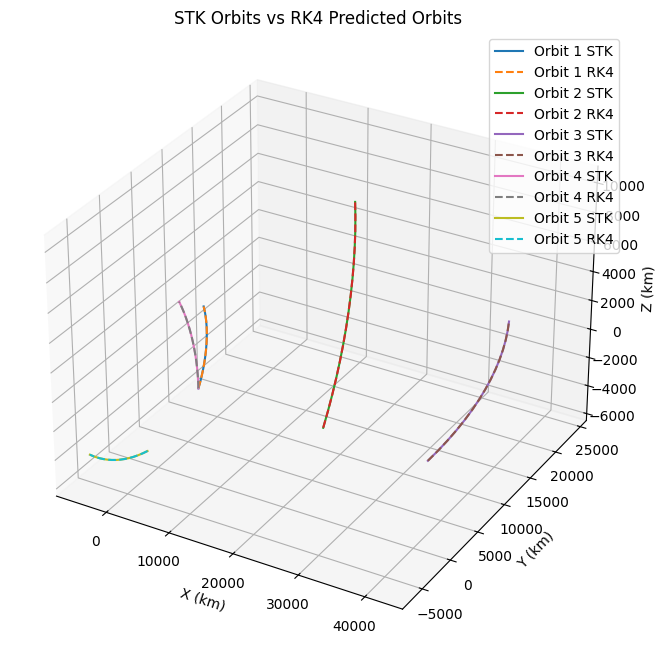

In [70]:
# ============================================================
# Cell 28: Plot RK4 Prediction vs STK Data
# This cell plots the RK4 predicted orbits against the STK
# reference orbits.
# ============================================================

fig = plt.figure(figsize=(10, 8))
ax = fig.add_subplot(111, projection="3d")

for name, res in rk4_results.items():
    actual = res["actual"]
    pred = res["pred"]

    ax.plot(actual[:, 0], actual[:, 1], actual[:, 2], label=f"{name} STK")
    ax.plot(pred[:, 0], pred[:, 1], pred[:, 2], linestyle="--", label=f"{name} RK4")

ax.set_title("STK Orbits vs RK4 Predicted Orbits")
ax.set_xlabel("X (km)")
ax.set_ylabel("Y (km)")
ax.set_zlabel("Z (km)")
ax.legend()
plt.show()

In [71]:
# ============================================================
# Cell 29: Prediction Confidence Score
# This cell calculates a confidence score for each orbit based
# on RK4 prediction error relative to the mean orbital radius.
# ============================================================

confidence_rows = []

for name, res in rk4_results.items():
    actual = res["actual"]
    errors = res["errors"]

    mean_radius = np.mean(np.linalg.norm(actual, axis=1))
    mean_error = np.mean(errors)
    max_error = np.max(errors)
    rmse = res["rmse"]

    confidence_score = 100 * (1 - (rmse / mean_radius))
    confidence_score = max(confidence_score, 0)

    confidence_rows.append({
        "Orbit": name,
        "RK4 RMSE km": rmse,
        "Mean Error km": mean_error,
        "Max Error km": max_error,
        "Mean Orbital Radius km": mean_radius,
        "Confidence Score %": confidence_score
    })

confidence_df = pd.DataFrame(confidence_rows)

confidence_df = confidence_df.sort_values(
    by="Confidence Score %",
    ascending=False
).reset_index(drop=True)

confidence_df

,Orbit,RK4 RMSE km,Mean Error km,Max Error km,Mean Orbital Radius km,Confidence Score %
0,Orbit 2,0.607264,0.521741,0.999681,26378.137000,99.997698
1,Orbit 3,1.125461,0.957794,1.915161,42164.137000,99.997331
2,Orbit 5,0.338255,0.289164,0.568554,7549.616157,99.995520
3,Orbit 1,3.272529,2.839692,5.201827,6878.137000,99.952421
4,Orbit 4,5.240697,4.459598,8.919530,6878.137000,99.923806


In [72]:
# ============================================================
# Cell 30: Final Reliability Decision
# This cell selects the most reliable predicted orbit based on
# the highest confidence score.
# ============================================================

best_confidence_orbit = confidence_df.iloc[0]

print("Most Reliable Predicted Orbit")
print("-----------------------------")
print(f"Orbit: {best_confidence_orbit['Orbit']}")
print(f"RK4 RMSE: {best_confidence_orbit['RK4 RMSE km']:.4f} km")
print(f"Mean Error: {best_confidence_orbit['Mean Error km']:.4f} km")
print(f"Max Error: {best_confidence_orbit['Max Error km']:.4f} km")
print(f"Confidence Score: {best_confidence_orbit['Confidence Score %']:.2f}%")

Most Reliable Predicted Orbit
-----------------------------
Orbit: Orbit 2
RK4 RMSE: 0.6073 km
Mean Error: 0.5217 km
Max Error: 0.9997 km
Confidence Score: 100.00%


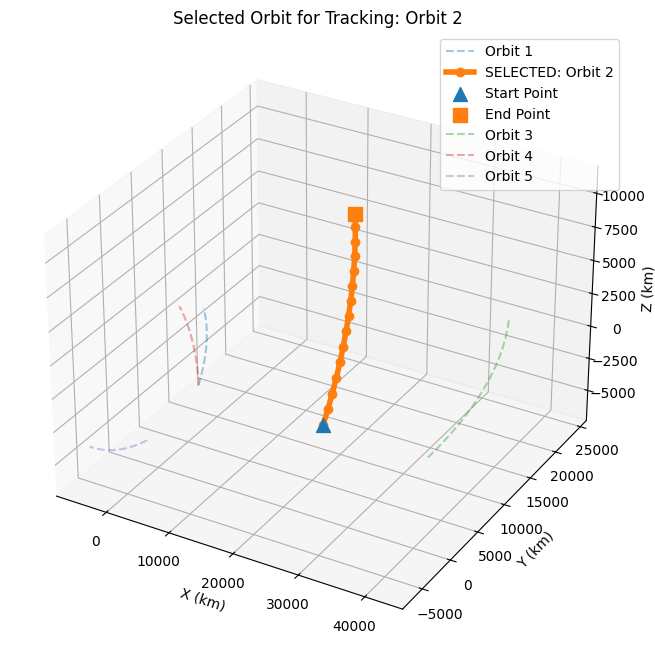

In [73]:
# ============================================================
# Cell 30A: Visual Summary of Selected Best Orbit
# This plot highlights the best orbit selected for autonomous tracking
# and compares it with the other orbits in 3D.
# ============================================================

selected_orbit_name = tracking_decision_df.iloc[0]["Orbit"]

fig = plt.figure(figsize=(11, 8))
ax = fig.add_subplot(111, projection="3d")

for name, df in orbit_data.items():
    pos = df[["x", "y", "z"]].values

    if name == selected_orbit_name:
        ax.plot(
            pos[:, 0], pos[:, 1], pos[:, 2],
            linewidth=4,
            marker="o",
            label=f"SELECTED: {name}"
        )

        ax.scatter(
            pos[0, 0], pos[0, 1], pos[0, 2],
            s=100,
            marker="^",
            label="Start Point"
        )

        ax.scatter(
            pos[-1, 0], pos[-1, 1], pos[-1, 2],
            s=100,
            marker="s",
            label="End Point"
        )

    else:
        ax.plot(
            pos[:, 0], pos[:, 1], pos[:, 2],
            linestyle="--",
            alpha=0.4,
            label=name
        )

ax.set_title(f"Selected Orbit for Tracking: {selected_orbit_name}")
ax.set_xlabel("X (km)")
ax.set_ylabel("Y (km)")
ax.set_zlabel("Z (km)")
ax.legend()
plt.show()

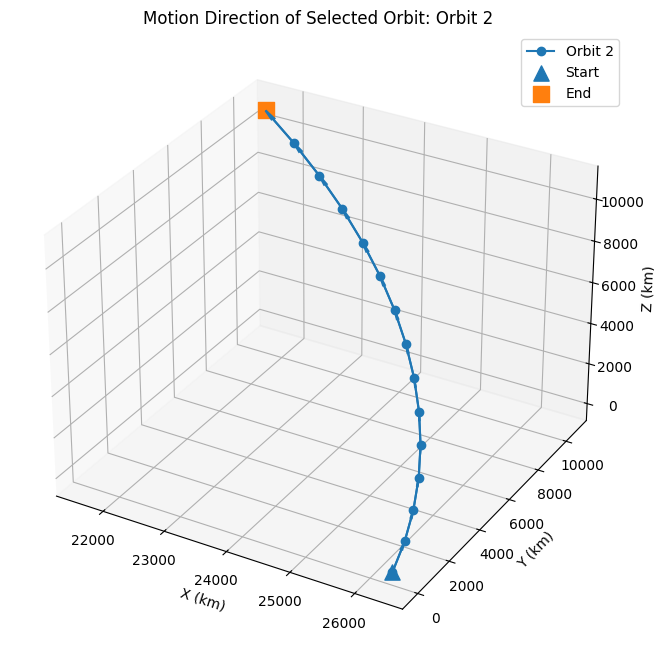

In [74]:
# ============================================================
# Cell 30B: Direction of Motion Plot for Selected Orbit
# This plot shows the satellite motion direction using arrows
# along the selected orbit trajectory.
# ============================================================

df_selected = orbit_data[selected_orbit_name]
pos = df_selected[["x", "y", "z"]].values

fig = plt.figure(figsize=(10, 8))
ax = fig.add_subplot(111, projection="3d")

ax.plot(pos[:, 0], pos[:, 1], pos[:, 2], marker="o", label=selected_orbit_name)

for k in range(len(pos) - 1):
    start = pos[k]
    direction = pos[k + 1] - pos[k]

    ax.quiver(
        start[0], start[1], start[2],
        direction[0], direction[1], direction[2],
        length=1,
        normalize=False
    )

ax.scatter(pos[0, 0], pos[0, 1], pos[0, 2], s=120, marker="^", label="Start")
ax.scatter(pos[-1, 0], pos[-1, 1], pos[-1, 2], s=120, marker="s", label="End")

ax.set_title(f"Motion Direction of Selected Orbit: {selected_orbit_name}")
ax.set_xlabel("X (km)")
ax.set_ylabel("Y (km)")
ax.set_zlabel("Z (km)")
ax.legend()
plt.show()

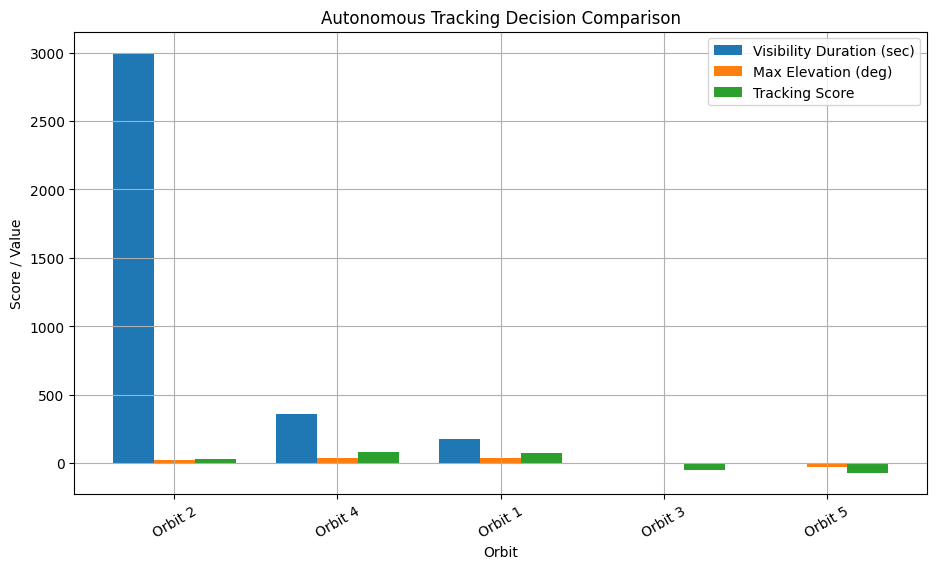

In [75]:
# ============================================================
# Cell 30C: Why This Orbit Was Selected
# This bar chart explains the tracking decision using visibility,
# elevation, and tracking score.
# ============================================================

plot_df = tracking_decision_df.copy()

x = np.arange(len(plot_df["Orbit"]))

plt.figure(figsize=(11, 6))
plt.bar(x - 0.25, plot_df["Visibility Duration sec"], width=0.25, label="Visibility Duration (sec)")
plt.bar(x, plot_df["Max Elevation deg"], width=0.25, label="Max Elevation (deg)")
plt.bar(x + 0.25, plot_df["Tracking Score"], width=0.25, label="Tracking Score")

plt.xticks(x, plot_df["Orbit"], rotation=30)
plt.title("Autonomous Tracking Decision Comparison")
plt.xlabel("Orbit")
plt.ylabel("Score / Value")
plt.grid(True)
plt.legend()
plt.show()

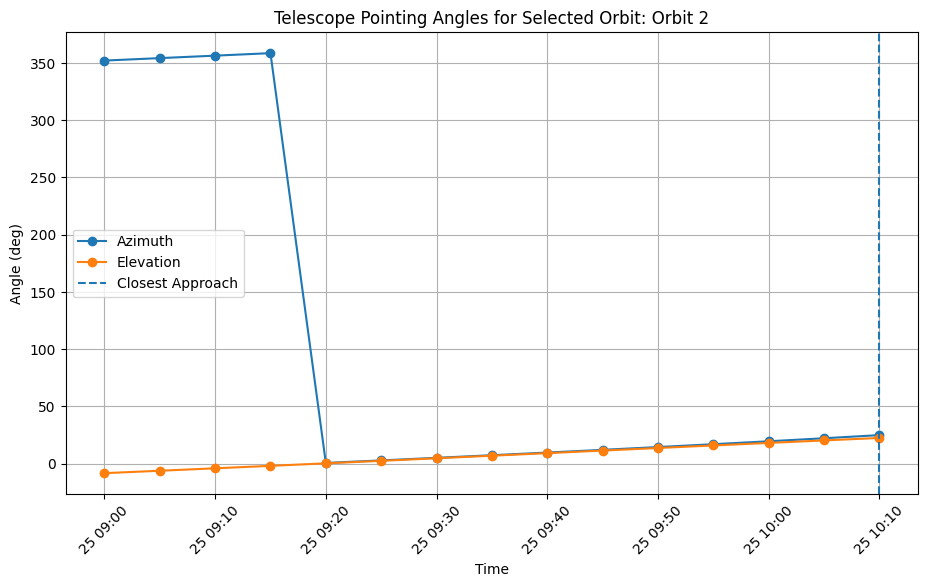

In [76]:
# ============================================================
# Cell 30D: Selected Orbit AER Tracking Plot
# This plot shows how the telescope should move in azimuth and
# elevation to track the selected orbit.
# ============================================================

selected_aer = aer_data[selected_orbit_name]

plt.figure(figsize=(11, 6))
plt.plot(selected_aer["time"], selected_aer["azimuth_deg"], marker="o", label="Azimuth")
plt.plot(selected_aer["time"], selected_aer["elevation_deg"], marker="o", label="Elevation")

best_time = tracking_decision_df.iloc[0]["Closest Approach Time"]

if best_time is not None:
    plt.axvline(best_time, linestyle="--", label="Closest Approach")

plt.title(f"Telescope Pointing Angles for Selected Orbit: {selected_orbit_name}")
plt.xlabel("Time")
plt.ylabel("Angle (deg)")
plt.grid(True)
plt.legend()
plt.xticks(rotation=45)
plt.show()

In [77]:
# ============================================================
# Cell 30E: Text Explanation of Selected Orbit
# This cell prints a clear explanation for the doctor showing
# which orbit was selected and why.
# ============================================================

selected_row = tracking_decision_df.iloc[0]
selected_confidence = confidence_df[confidence_df["Orbit"] == selected_orbit_name]

print("Selected Orbit Explanation")
print("--------------------------")
print(f"Selected Orbit: {selected_orbit_name}")
print(f"Reason: This orbit has the best tracking conditions based on visibility duration, maximum elevation, and tracking score.")
print(f"AOS Time: {selected_row['AOS Time']}")
print(f"Closest Approach Time: {selected_row['Closest Approach Time']}")
print(f"LOS Time: {selected_row['LOS Time']}")
print(f"Visibility Duration: {selected_row['Visibility Duration sec']} sec")
print(f"Maximum Elevation: {selected_row['Max Elevation deg']:.2f} deg")
print(f"Minimum Range: {selected_row['Minimum Range km']:.2f} km")
print(f"Tracking Score: {selected_row['Tracking Score']:.2f}")

if len(selected_confidence) > 0:
    print(f"Prediction Confidence: {selected_confidence.iloc[0]['Confidence Score %']:.2f}%")

Selected Orbit Explanation
--------------------------
Selected Orbit: Orbit 2
Reason: This orbit has the best tracking conditions based on visibility duration, maximum elevation, and tracking score.
AOS Time: 2026-04-25 09:20:00
Closest Approach Time: 2026-04-25 10:10:00
LOS Time: 2026-04-25 10:10:00
Visibility Duration: 3000.0 sec
Maximum Elevation: 22.48 deg
Minimum Range: 20054.52 km
Tracking Score: 30.41
Prediction Confidence: 100.00%


In [78]:
# ============================================================
# Cell 31: Export All Reports as CSV Files
# This cell exports all final project tables and reports as CSV
# files for documentation and submission.
# ============================================================

report.to_csv("final_orbital_elements_report.csv", index=False)
closest_pass_df.to_csv("closest_pass_report.csv", index=False)
error_summary_df.to_csv("error_analysis_report.csv", index=False)
two_point_df.to_csv("two_point_orbital_elements_report.csv", index=False)
best_pass_df.to_csv("best_pass_selection_report.csv", index=False)
best_two_points_df.to_csv("best_two_points_auto_selection_report.csv", index=False)
comparison_df.to_csv("initial_vs_best_two_points_comparison.csv", index=False)
visibility_window_df.to_csv("visibility_window_AOS_LOS_report.csv", index=False)
tracking_decision_df.to_csv("final_autonomous_tracking_decision.csv", index=False)
rk4_comparison_df.to_csv("euler_vs_rk4_comparison_report.csv", index=False)
confidence_df.to_csv("orbit_prediction_confidence_report.csv", index=False)

for name, gt in ground_tracks.items():
    safe_name = name.replace(" ", "_")
    gt.to_csv(f"{safe_name}_ground_track.csv", index=False)

for name, aer in aer_data.items():
    safe_name = name.replace(" ", "_")
    aer.to_csv(f"{safe_name}_AER.csv", index=False)

for name, cmd in tracking_commands.items():
    safe_name = name.replace(" ", "_")
    cmd.to_csv(f"{safe_name}_tracking_motor_commands.csv", index=False)

print("All reports exported successfully.")

All reports exported successfully.


In [79]:
# ============================================================
# Cell 32: Final Project Conclusion
# This cell generates a final professional conclusion describing
# the complete autonomous satellite tracking workflow.
# ============================================================

final_conclusion = f"""
Final Project Conclusion:

In this project, five different satellite orbits were generated using STK.
For each orbit, J2000 position and velocity data were exported and used as input to the Python model.

The developed system performs the following tasks:

1. Reads STK position and velocity data for five different orbits.
2. Uses random STK points to estimate orbital behavior.
3. Calculates the main orbital elements:
   - Semi-major axis
   - Eccentricity
   - Inclination
   - RAAN
   - Argument of perigee
   - True anomaly
4. Determines the satellite motion direction.
5. Predicts the future trajectory using two-body propagation.
6. Compares the predicted trajectory with STK reference data using RMSE.
7. Calculates ground tracks for all five orbits.
8. Performs AER analysis relative to Beni Suef ground station.
9. Selects the closest and best tracking pass.
10. Estimates satellite velocity using only two STK position points and timestamps.
11. Automatically classifies each orbit type.
12. Selects the best two points that minimize prediction error.
13. Generates telescope tracking commands:
    - Azimuth
    - Elevation
    - Azimuth rate
    - Elevation rate
14. Determines AOS, closest approach, maximum elevation time, and LOS.
15. Improves orbit prediction accuracy using RK4 propagation.
16. Calculates a prediction confidence score for each orbit.

Best orbit to track from Beni Suef:
Orbit: {tracking_decision_df.iloc[0]['Orbit']}
AOS Time: {tracking_decision_df.iloc[0]['AOS Time']}
Closest Approach Time: {tracking_decision_df.iloc[0]['Closest Approach Time']}
LOS Time: {tracking_decision_df.iloc[0]['LOS Time']}
Maximum Elevation: {tracking_decision_df.iloc[0]['Max Elevation deg']:.2f} deg

Most reliable predicted orbit:
Orbit: {best_confidence_orbit['Orbit']}
RK4 RMSE: {best_confidence_orbit['RK4 RMSE km']:.4f} km
Confidence Score: {best_confidence_orbit['Confidence Score %']:.2f}%

This makes the project close to a complete autonomous satellite tracking workflow because it does not only reconstruct and predict the orbit, but also selects the best tracking pass and generates telescope pointing commands.
"""

print(final_conclusion)


Final Project Conclusion:

In this project, five different satellite orbits were generated using STK.
For each orbit, J2000 position and velocity data were exported and used as input to the Python model.

The developed system performs the following tasks:

1. Reads STK position and velocity data for five different orbits.
2. Uses random STK points to estimate orbital behavior.
3. Calculates the main orbital elements:
   - Semi-major axis
   - Eccentricity
   - Inclination
   - RAAN
   - Argument of perigee
   - True anomaly
4. Determines the satellite motion direction.
5. Predicts the future trajectory using two-body propagation.
6. Compares the predicted trajectory with STK reference data using RMSE.
7. Calculates ground tracks for all five orbits.
8. Performs AER analysis relative to Beni Suef ground station.
9. Selects the closest and best tracking pass.
10. Estimates satellite velocity using only two STK position points and timestamps.
11. Automatically classifies each orbit type.

In [80]:
# ============================================================
# Cell 33: Install Skyfield for Real-Time Satellite Tracking
# This installs the Skyfield library to work with TLE data.
# ============================================================

!pip install skyfield

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 370.4/370.4 kB 10.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 49.6/49.6 kB 3.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 235.7/235.7 kB 18.8 MB/s eta 0:00:00


In [81]:
# ============================================================
# Cell 34: Load Real-Time TLE Data
# This cell loads real satellite data (ISS) using TLE format.
# ============================================================

from skyfield.api import load, EarthSatellite

# ISS TLE (ممكن تغيريه لأي قمر بعدين)
tle_lines = [
    "1 25544U 98067A   24070.54791667  .00016717  00000+0  10270-3 0  9001",
    "2 25544  51.6433  21.3205 0004377  90.2456  15.3456 15.50000000 00001"
]

satellite = EarthSatellite(tle_lines[0], tle_lines[1], "ISS")

ts = load.timescale()

print("TLE Loaded Successfully")

TLE Loaded Successfully


In [82]:
# ============================================================
# Cell 35: Real-Time Orbit Propagation from TLE
# This cell computes satellite position over time using real TLE data.
# ============================================================

times = ts.utc(2024, 3, 10, range(0, 60))  # 60 minutes

geocentric = satellite.at(times)
position = geocentric.position.km

x_tle = position[0]
y_tle = position[1]
z_tle = position[2]

print("Real-time orbit calculated from TLE")

Real-time orbit calculated from TLE


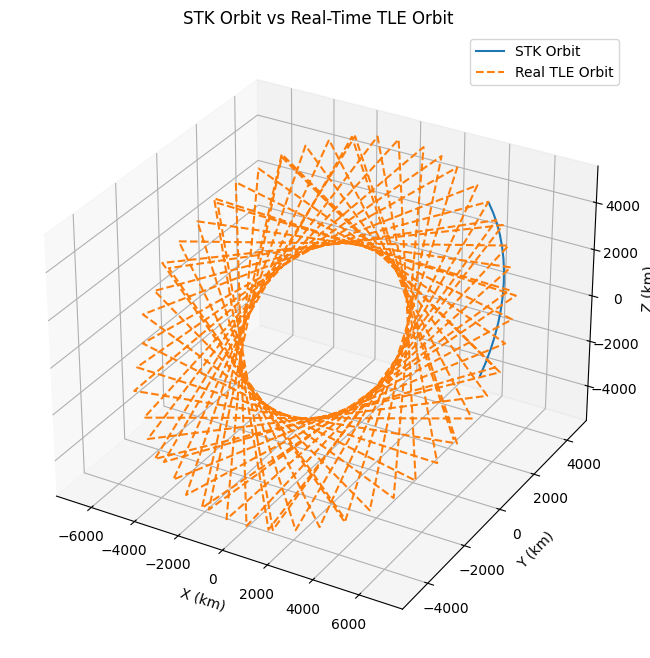

In [83]:
# ============================================================
# Cell 36: Compare Real TLE Orbit with STK Orbit
# This plot compares real satellite orbit with STK-based orbit.
# ============================================================

fig = plt.figure(figsize=(10, 8))
ax = fig.add_subplot(111, projection="3d")

# STK Orbit (مثلاً Orbit 1)
stk = orbit_data["Orbit 1"][["x", "y", "z"]].values

ax.plot(stk[:,0], stk[:,1], stk[:,2], label="STK Orbit")

# TLE Orbit
ax.plot(x_tle, y_tle, z_tle, linestyle="--", label="Real TLE Orbit")

ax.set_title("STK Orbit vs Real-Time TLE Orbit")
ax.set_xlabel("X (km)")
ax.set_ylabel("Y (km)")
ax.set_zlabel("Z (km)")
ax.legend()

plt.show()

In [84]:
# ============================================================
# Cell 33: Install Skyfield for Live TLE Satellite Tracking
# This cell installs Skyfield, which is used to propagate real
# satellites from live TLE data.
# ============================================================

!pip install skyfield

In [85]:
# ============================================================
# Cell 34: Download Live TLE Data from CelesTrak
# This cell downloads live TLE data for active/station satellites
# from CelesTrak and loads them into Skyfield.
# ============================================================

from skyfield.api import load, wgs84
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

ts = load.timescale()

# Live TLE source from CelesTrak
tle_url = "https://celestrak.org/NORAD/elements/gp.php?GROUP=stations&FORMAT=tle"

satellites = load.tle_file(tle_url)
print(f"Loaded {len(satellites)} satellites from live TLE data")

for sat in satellites[:5]:
    print(sat.name)

[#################################] 100% gp.php


Loaded 27 satellites from live TLE data
ISS (ZARYA)
POISK
CSS (TIANHE)
ISS (NAUKA)
FREGAT DEB


In [86]:
# ============================================================
# Cell 35: Define Beni Suef Ground Station for Live TLE Tracking
# This cell defines the observer location used to evaluate real
# satellite passes over Beni Suef, Egypt.
# ============================================================

BENI_SUEF_LAT = 29.0661
BENI_SUEF_LON = 31.0994

beni_suef_station = wgs84.latlon(BENI_SUEF_LAT, BENI_SUEF_LON)

print("Ground station defined:")
print("Beni Suef, Egypt")

Ground station defined:
Beni Suef, Egypt


In [87]:
# ============================================================
# Cell 36: Predict Live TLE Satellite Passes
# This cell calculates azimuth, elevation, and range for each
# live satellite over the next 2 hours.
# ============================================================

from datetime import datetime, timedelta, timezone

start_time = datetime.now(timezone.utc)
minutes = np.arange(0, 120, 1)

times = ts.utc(
    start_time.year,
    start_time.month,
    start_time.day,
    start_time.hour,
    start_time.minute + minutes
)

live_pass_results = []

for sat in satellites:
    difference = sat - beni_suef_station
    topocentric = difference.at(times)

    alt, az, distance = topocentric.altaz()

    max_elevation = np.max(alt.degrees)
    min_range = np.min(distance.km)
    visible_points = np.sum(alt.degrees > 0)

    if visible_points > 0:
        best_idx = np.argmax(alt.degrees)

        live_pass_results.append({
            "Satellite": sat.name,
            "Max Elevation deg": max_elevation,
            "Minimum Range km": min_range,
            "Visible Minutes": visible_points,
            "Best Time UTC": start_time + timedelta(minutes=int(best_idx)),
            "Tracking Score": (max_elevation * 2) - (min_range / 1000) + (visible_points * 0.5)
        })

live_pass_df = pd.DataFrame(live_pass_results)

live_pass_df = live_pass_df.sort_values(
    by="Tracking Score",
    ascending=False
).reset_index(drop=True)

live_pass_df.head(10)

,Satellite,Max Elevation deg,Minimum Range km,Visible Minutes,Best Time UTC,Tracking Score
0,HMU-SAT2,60.600519,450.160335,14,2026-04-25 22:18:03.734109+00:00,127.750878
1,ISS OBJECT XY,54.769781,417.208430,12,2026-04-25 22:01:03.734109+00:00,115.122354
2,HRC MONOBLOCK CAMERA,55.211795,439.843115,10,2026-04-25 21:37:03.734109+00:00,114.983747
3,ISS OBJECT XU,51.373101,357.599005,8,2026-04-25 21:30:03.734109+00:00,106.388603
4,ISS OBJECT XW,43.798019,425.284031,8,2026-04-25 21:43:03.734109+00:00,91.170754
5,FREGAT DEB,39.289058,2391.497242,26,2026-04-25 21:37:03.734109+00:00,89.186618
6,ISS OBJECT XT,38.168955,447.679055,9,2026-04-25 21:47:03.734109+00:00,80.390232
7,GXIBA-1,37.311222,615.887768,10,2026-04-25 22:03:03.734109+00:00,79.006556
8,HTV-X1,27.103640,912.289195,11,2026-04-25 22:22:03.734109+00:00,58.794991
9,CORAL,18.612040,969.192372,10,2026-04-25 21:35:03.734109+00:00,41.254887


In [88]:
# ============================================================
# Cell 37: Select Best Real Satellite to Track
# This cell selects the best real satellite from live TLE data
# based on visibility, elevation, range, and tracking score.
# ============================================================

if len(live_pass_df) > 0:
    best_live_satellite = live_pass_df.iloc[0]

    print("Best Real Satellite to Track from Beni Suef")
    print("-------------------------------------------")
    print(f"Satellite: {best_live_satellite['Satellite']}")
    print(f"Best Time UTC: {best_live_satellite['Best Time UTC']}")
    print(f"Max Elevation: {best_live_satellite['Max Elevation deg']:.2f} deg")
    print(f"Minimum Range: {best_live_satellite['Minimum Range km']:.2f} km")
    print(f"Visible Minutes: {best_live_satellite['Visible Minutes']}")
    print(f"Tracking Score: {best_live_satellite['Tracking Score']:.2f}")

else:
    print("No visible satellite passes found in the next 2 hours.")

Best Real Satellite to Track from Beni Suef
-------------------------------------------
Satellite: HMU-SAT2
Best Time UTC: 2026-04-25 22:18:03.734109+00:00
Max Elevation: 60.60 deg
Minimum Range: 450.16 km
Visible Minutes: 14
Tracking Score: 127.75


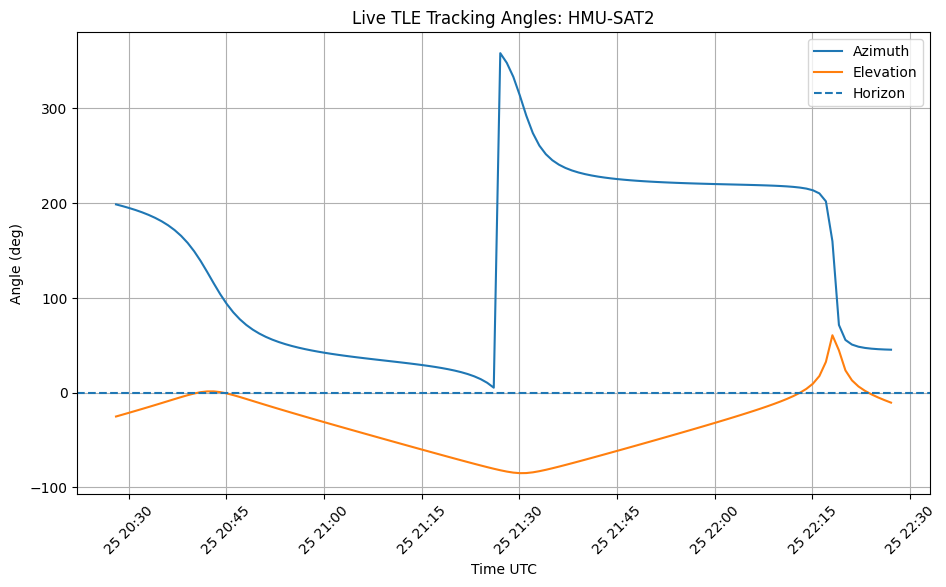

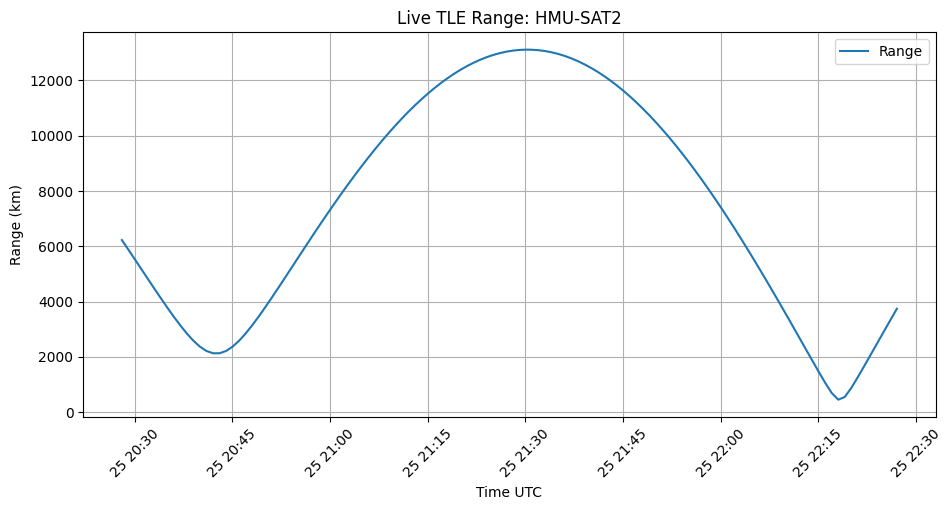

,time_utc,azimuth_deg,elevation_deg,range_km
0,2026-04-25 20:28:03.734109+00:00,198.621800,-25.109666,6223.797686
1,2026-04-25 20:29:03.734109+00:00,196.811925,-23.145424,5873.846980
2,2026-04-25 20:30:03.734109+00:00,194.846240,-21.163808,5521.210657
3,2026-04-25 20:31:03.734109+00:00,192.684968,-19.163021,5167.093514
4,2026-04-25 20:32:03.734109+00:00,190.277796,-17.141135,4812.951060


In [89]:
# ============================================================
# Cell 38: Plot Best Live Satellite AER Tracking Angles
# This cell plots azimuth, elevation, and range for the selected
# real satellite using live TLE data.
# ============================================================

if len(live_pass_df) > 0:
    best_sat_name = best_live_satellite["Satellite"]

    selected_sat = None
    for sat in satellites:
        if sat.name == best_sat_name:
            selected_sat = sat
            break

    difference = selected_sat - beni_suef_station
    topocentric = difference.at(times)

    alt, az, distance = topocentric.altaz()

    live_aer_df = pd.DataFrame({
        "time_utc": [start_time + timedelta(minutes=int(m)) for m in minutes],
        "azimuth_deg": az.degrees,
        "elevation_deg": alt.degrees,
        "range_km": distance.km
    })

    plt.figure(figsize=(11, 6))
    plt.plot(live_aer_df["time_utc"], live_aer_df["azimuth_deg"], label="Azimuth")
    plt.plot(live_aer_df["time_utc"], live_aer_df["elevation_deg"], label="Elevation")
    plt.axhline(0, linestyle="--", label="Horizon")

    plt.title(f"Live TLE Tracking Angles: {best_sat_name}")
    plt.xlabel("Time UTC")
    plt.ylabel("Angle (deg)")
    plt.grid(True)
    plt.legend()
    plt.xticks(rotation=45)
    plt.show()

    plt.figure(figsize=(11, 5))
    plt.plot(live_aer_df["time_utc"], live_aer_df["range_km"], label="Range")

    plt.title(f"Live TLE Range: {best_sat_name}")
    plt.xlabel("Time UTC")
    plt.ylabel("Range (km)")
    plt.grid(True)
    plt.legend()
    plt.xticks(rotation=45)
    plt.show()

    display(live_aer_df.head())

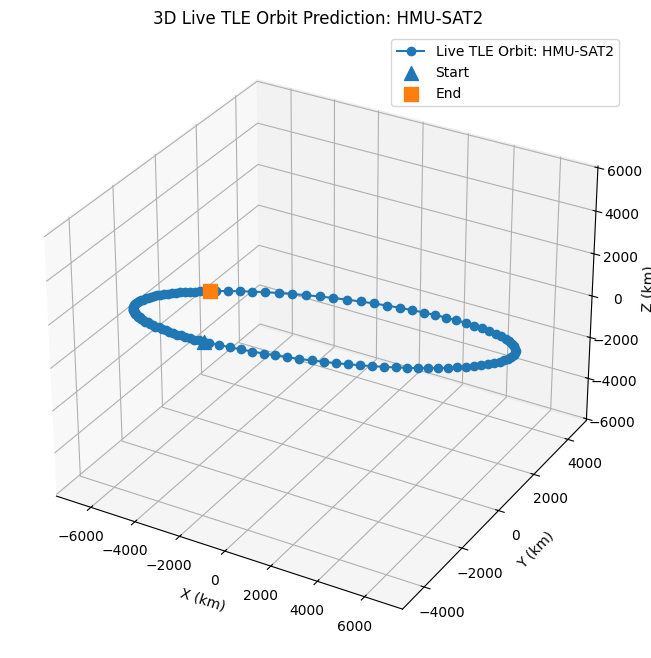

In [90]:
# ============================================================
# Cell 39: Plot Live TLE Orbit in 3D
# This cell plots the ECI position of the selected real satellite
# propagated from live TLE data.
# ============================================================

if len(live_pass_df) > 0:
    geocentric = selected_sat.at(times)
    pos = geocentric.position.km

    fig = plt.figure(figsize=(10, 8))
    ax = fig.add_subplot(111, projection="3d")

    ax.plot(pos[0], pos[1], pos[2], marker="o", label=f"Live TLE Orbit: {best_sat_name}")

    ax.scatter(pos[0][0], pos[1][0], pos[2][0], s=100, marker="^", label="Start")
    ax.scatter(pos[0][-1], pos[1][-1], pos[2][-1], s=100, marker="s", label="End")

    ax.set_title(f"3D Live TLE Orbit Prediction: {best_sat_name}")
    ax.set_xlabel("X (km)")
    ax.set_ylabel("Y (km)")
    ax.set_zlabel("Z (km)")
    ax.legend()
    plt.show()

In [91]:
# ============================================================
# Cell 40: Export Live TLE Tracking Results
# This cell exports the live TLE pass ranking and selected
# satellite tracking data.
# ============================================================

live_pass_df.to_csv("live_TLE_best_satellite_passes.csv", index=False)

if len(live_pass_df) > 0:
    live_aer_df.to_csv("live_TLE_selected_satellite_AER.csv", index=False)

print("Live TLE tracking reports exported successfully.")

Live TLE tracking reports exported successfully.


In [93]:
# ============================================================
# AI-Based Tracking Decision (Simple ML Model)
# This model learns how to select the best orbit automatically
# ============================================================

from sklearn.ensemble import RandomForestRegressor
from sklearn.model_selection import train_test_split

# استخدمي البيانات اللي عندك
df = best_pass_df.copy()

# Features
X = df[[
    "Max Elevation deg",
    "Minimum Range km",
    "Visible Points",
    "Estimated Visibility Duration sec"
]]

# Target (tracking score القديم)
y = df["Tracking Score"]

# تقسيم البيانات
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2)

# Model
model = RandomForestRegressor(n_estimators=100)
model.fit(X_train, y_train)

# Prediction
df["AI Score"] = model.predict(X)

# ترتيب حسب AI
df = df.sort_values(by="AI Score", ascending=False)

df

,Orbit,Best Time,Max Elevation deg,Minimum Range km,Visible Points,Estimated Visibility Duration sec,Tracking Score,AI Score
0,Orbit 4,2026-04-25 09:14:00,38.886197,3147.722000,7,420,78.124673,71.218142
1,Orbit 1,2026-04-25 09:13:00,35.174008,521.120415,4,240,71.826895,68.950942
2,Orbit 2,2026-04-25 10:10:00,22.480005,20054.518840,11,660,30.405491,27.649970
4,Orbit 5,2026-04-25 09:14:00,-28.223971,12118.366179,0,0,-68.566308,-47.352331
3,Orbit 3,2026-04-25 09:00:00,-4.885271,36729.339757,0,0,-46.499882,-48.908014


In [94]:
# ============================================================
# Cell: Improved AI-Based Tracking Decision
# This improves the AI model by using normalized features and
# creating an independent AI decision score.
# ============================================================

from sklearn.ensemble import RandomForestRegressor
import numpy as np
import pandas as pd

ai_df = best_pass_df.copy()

# Normalize features
ai_df["elevation_norm"] = ai_df["Max Elevation deg"] / ai_df["Max Elevation deg"].max()
ai_df["range_norm"] = 1 - (ai_df["Minimum Range km"] / ai_df["Minimum Range km"].max())
ai_df["visibility_norm"] = ai_df["Estimated Visibility Duration sec"] / ai_df["Estimated Visibility Duration sec"].max()

# Independent AI target score
ai_df["AI Target Score"] = (
    0.45 * ai_df["elevation_norm"] +
    0.35 * ai_df["visibility_norm"] +
    0.20 * ai_df["range_norm"]
) * 100

X = ai_df[[
    "Max Elevation deg",
    "Minimum Range km",
    "Visible Points",
    "Estimated Visibility Duration sec"
]]

y = ai_df["AI Target Score"]

model = RandomForestRegressor(
    n_estimators=300,
    random_state=42
)

model.fit(X, y)

ai_df["Improved AI Score"] = model.predict(X)

ai_df = ai_df.sort_values(
    by="Improved AI Score",
    ascending=False
).reset_index(drop=True)

ai_df

,Orbit,Best Time,Max Elevation deg,Minimum Range km,Visible Points,Estimated Visibility Duration sec,Tracking Score,elevation_norm,range_norm,visibility_norm,AI Target Score,Improved AI Score
0,Orbit 4,2026-04-25 09:14:00,38.886197,3147.722000,7,420,78.124673,1.000000,0.914300,0.636364,85.558718,80.886751
1,Orbit 1,2026-04-25 09:13:00,35.174008,521.120415,4,240,71.826895,0.904537,0.985812,0.363636,73.147679,72.004016
2,Orbit 2,2026-04-25 10:10:00,22.480005,20054.518840,11,660,30.405491,0.578097,0.453992,1.000000,70.094214,64.019153
3,Orbit 3,2026-04-25 09:00:00,-4.885271,36729.339757,0,0,-46.499882,-0.125630,0.000000,0.000000,-5.653348,-3.382489
4,Orbit 5,2026-04-25 09:14:00,-28.223971,12118.366179,0,0,-68.566308,-0.725809,0.670063,0.000000,-19.260166,-5.327107


In [95]:
# ============================================================
# Cell: Compare Traditional Score vs Improved AI Score
# This cell compares the original tracking score with the AI score.
# ============================================================

comparison_ai_df = ai_df[[
    "Orbit",
    "Tracking Score",
    "AI Target Score",
    "Improved AI Score",
    "Max Elevation deg",
    "Minimum Range km",
    "Estimated Visibility Duration sec"
]]

comparison_ai_df

,Orbit,Tracking Score,AI Target Score,Improved AI Score,Max Elevation deg,Minimum Range km,Estimated Visibility Duration sec
0,Orbit 4,78.124673,85.558718,80.886751,38.886197,3147.722000,420
1,Orbit 1,71.826895,73.147679,72.004016,35.174008,521.120415,240
2,Orbit 2,30.405491,70.094214,64.019153,22.480005,20054.518840,660
3,Orbit 3,-46.499882,-5.653348,-3.382489,-4.885271,36729.339757,0
4,Orbit 5,-68.566308,-19.260166,-5.327107,-28.223971,12118.366179,0


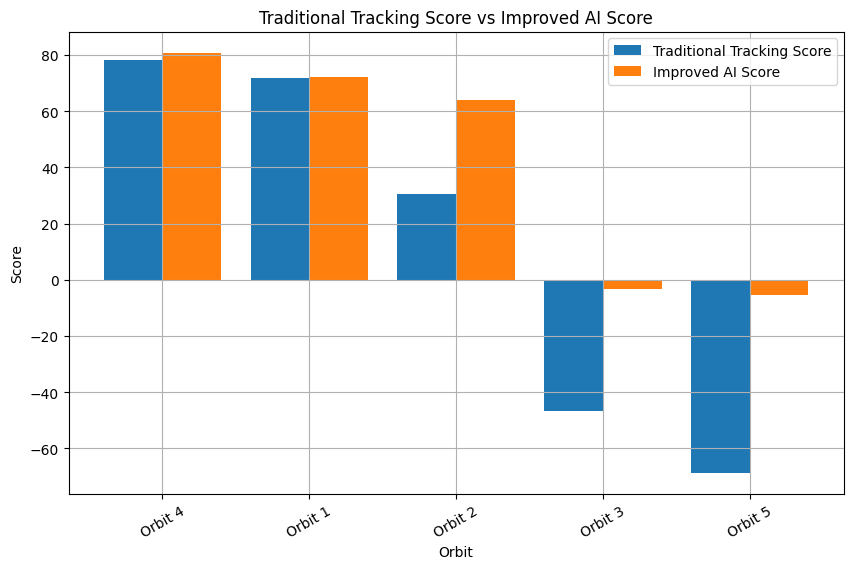

In [96]:
# ============================================================
# Cell: Plot Traditional Score vs AI Score
# This graph visually compares the original decision system
# with the improved AI-based decision system.
# ============================================================

plt.figure(figsize=(10, 6))

x = np.arange(len(ai_df["Orbit"]))

plt.bar(x - 0.2, ai_df["Tracking Score"], width=0.4, label="Traditional Tracking Score")
plt.bar(x + 0.2, ai_df["Improved AI Score"], width=0.4, label="Improved AI Score")

plt.xticks(x, ai_df["Orbit"], rotation=30)
plt.title("Traditional Tracking Score vs Improved AI Score")
plt.xlabel("Orbit")
plt.ylabel("Score")
plt.grid(True)
plt.legend()
plt.show()

In [97]:
# ============================================================
# Cell: Final AI-Based Orbit Selection
# This cell selects the best orbit according to the improved AI model.
# ============================================================

best_ai_orbit = ai_df.iloc[0]

print("Best Orbit Selected by Improved AI Model")
print("----------------------------------------")
print(f"Orbit: {best_ai_orbit['Orbit']}")
print(f"Traditional Tracking Score: {best_ai_orbit['Tracking Score']:.2f}")
print(f"Improved AI Score: {best_ai_orbit['Improved AI Score']:.2f}")
print(f"Max Elevation: {best_ai_orbit['Max Elevation deg']:.2f} deg")
print(f"Minimum Range: {best_ai_orbit['Minimum Range km']:.2f} km")
print(f"Visibility Duration: {best_ai_orbit['Estimated Visibility Duration sec']} sec")

Best Orbit Selected by Improved AI Model
----------------------------------------
Orbit: Orbit 4
Traditional Tracking Score: 78.12
Improved AI Score: 80.89
Max Elevation: 38.89 deg
Minimum Range: 3147.72 km
Visibility Duration: 420 sec


In [98]:
# ============================================================
# Cell: Export Improved AI Results
# This cell exports the AI-based tracking decision results.
# ============================================================

ai_df.to_csv("improved_ai_tracking_results.csv", index=False)
comparison_ai_df.to_csv("traditional_vs_ai_tracking_comparison.csv", index=False)

print("AI reports exported successfully.")

AI reports exported successfully.


In [99]:
# ============================================================
# Final System Summary Dashboard
# This cell summarizes all decision outputs from the project.
# ============================================================

summary_dashboard = pd.DataFrame([
    {
        "Decision Module": "Traditional Tracking Score",
        "Selected Target": best_pass_df.iloc[0]["Orbit"],
        "Main Reason": "Highest tracking score based on elevation, range, and visibility"
    },
    {
        "Decision Module": "Improved AI Model",
        "Selected Target": best_ai_orbit["Orbit"],
        "Main Reason": "Highest AI score using normalized tracking features"
    },
    {
        "Decision Module": "RK4 Reliability",
        "Selected Target": best_confidence_orbit["Orbit"],
        "Main Reason": "Highest prediction confidence score"
    },
    {
        "Decision Module": "Live TLE Tracking",
        "Selected Target": best_live_satellite["Satellite"],
        "Main Reason": "Best real satellite pass from live TLE data"
    }
])

summary_dashboard

,Decision Module,Selected Target,Main Reason
0,Traditional Tracking Score,Orbit 4,"Highest tracking score based on elevation, ran..."
1,Improved AI Model,Orbit 4,Highest AI score using normalized tracking fea...
2,RK4 Reliability,Orbit 2,Highest prediction confidence score
3,Live TLE Tracking,HMU-SAT2,Best real satellite pass from live TLE data


In [100]:
summary_dashboard.to_csv("final_system_summary_dashboard.csv", index=False)

In [102]:
# ============================================================
# Final Decision Analysis (Traditional vs AI) - Safe Version
# ============================================================

# Choose the correct dataframe
final_ai_df = ai_df.copy() if "ai_df" in globals() else df.copy()

# Detect AI score column automatically
if "Improved AI Score" in final_ai_df.columns:
    ai_score_col = "Improved AI Score"
elif "AI Score" in final_ai_df.columns:
    ai_score_col = "AI Score"
else:
    raise ValueError("No AI score column found. Run the AI model cell first.")

# Best orbit using traditional method
best_traditional = final_ai_df.loc[
    final_ai_df["Tracking Score"].idxmax(), "Orbit"
]

# Best orbit using AI
best_ai = final_ai_df.loc[
    final_ai_df[ai_score_col].idxmax(), "Orbit"
]

# Decision confidence indicator
final_ai_df["Decision Confidence"] = abs(
    final_ai_df[ai_score_col] - final_ai_df["Tracking Score"]
)

print("===== FINAL DECISION =====")
print(f"Best Orbit (Traditional): {best_traditional}")
print(f"Best Orbit (AI): {best_ai}")

print("\n===== CONFIDENCE ANALYSIS =====")
display(final_ai_df[["Orbit", "Tracking Score", ai_score_col, "Decision Confidence"]])

final_ai_df.to_csv("final_ai_decision_analysis.csv", index=False)

===== FINAL DECISION =====
Best Orbit (Traditional): Orbit 4
Best Orbit (AI): Orbit 4

===== CONFIDENCE ANALYSIS =====


,Orbit,Tracking Score,Improved AI Score,Decision Confidence
0,Orbit 4,78.124673,80.886751,2.762078
1,Orbit 1,71.826895,72.004016,0.177121
2,Orbit 2,30.405491,64.019153,33.613662
3,Orbit 3,-46.499882,-3.382489,43.117394
4,Orbit 5,-68.566308,-5.327107,63.239201
